In [21]:
import wandb
import pandas as pd
import matplotlib.pyplot as plt

entity = "18920011663-king-s-college-london"
project = "World_Model_Curriculum_Learning"          
prefixes = ["CL_WM_without_editing", "CL_WM_without_RB", "CL_WM*"]           
# Define the keys for the data you want to extract
step_key = "curriculum_step"
metric_name = "final_task_performance"
api = wandb.Api(timeout=60)
runs = api.runs(f"{entity}/{project}")
step_min, step_max = 0, 50  # Step range to display


Group 'CL_WM_without_editing': Found 3 runs
  Loaded CL_WM_without_editing_2
  Loaded CL_WM_without_editing_1
  Loaded CL_WM_without_editing

Group 'CL_WM_without_RB': Found 3 runs
  Loaded CL_WM_without_RB_2
  Loaded CL_WM_without_RB_1
  Loaded CL_WM_without_RB

Group 'CL_WM*': Found 3 runs
  Loaded CL_WM*_1
  Loaded CL_WM*_2
  Loaded CL_WM*


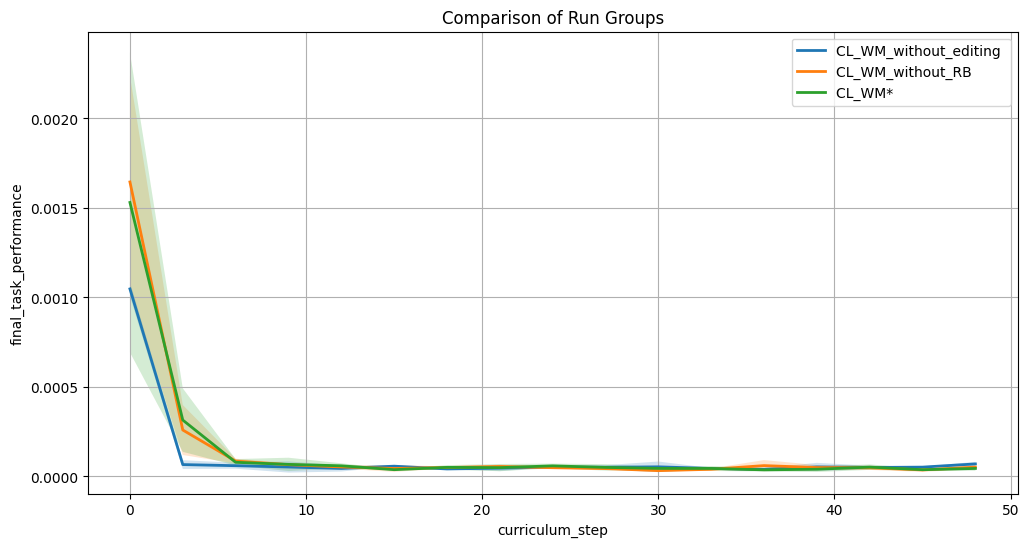

In [22]:
def load_group(prefix):
    runs = api.runs(f"{entity}/{project}")
    selected_runs = [run for run in runs if run.name.startswith(prefix)]
    print(f"\nGroup '{prefix}': Found {len(selected_runs)} runs")

    data_frames = []
    for run in selected_runs:
        try:
            history = run.history()
            if metric_name not in history.columns or step_key not in history.columns:
                print(f"Skipping {run.name}: missing '{metric_name}' or '{step_key}'")
                continue
            df = history[[step_key, metric_name]].dropna()
            df = df.groupby(step_key).mean().reset_index()
            df.rename(columns={metric_name: run.name}, inplace=True)
            data_frames.append(df.set_index(step_key))
            print(f"  Loaded {run.name}")
        except Exception as e:
            print(f"  Error loading {run.name}: {e}")

    if not data_frames:
        return None, None, None
    
    merged_df = pd.concat(data_frames, axis=1)
    mean = merged_df.mean(axis=1)
    std = merged_df.std(axis=1)

    return merged_df.index, mean, std

plt.figure(figsize=(12, 6))

for prefix in prefixes:
    steps, mean, std = load_group(prefix)
    if steps is None:
        continue
    
    # Filter to only include step range 0 to 50
    step_mask = (steps >= step_min) & (steps <= step_max)
    steps_filtered = steps[step_mask]
    mean_filtered = mean[step_mask]
    std_filtered = std[step_mask]
    
    plt.plot(steps_filtered, mean_filtered, linewidth=2, label=f"{prefix} ")
    plt.fill_between(steps_filtered, mean_filtered - std_filtered, mean_filtered + std_filtered, alpha=0.2)

plt.xlabel(step_key)
plt.ylabel(metric_name)
plt.title(f"Comparison of Run Groups")
plt.legend()
plt.grid(True)
plt.show()

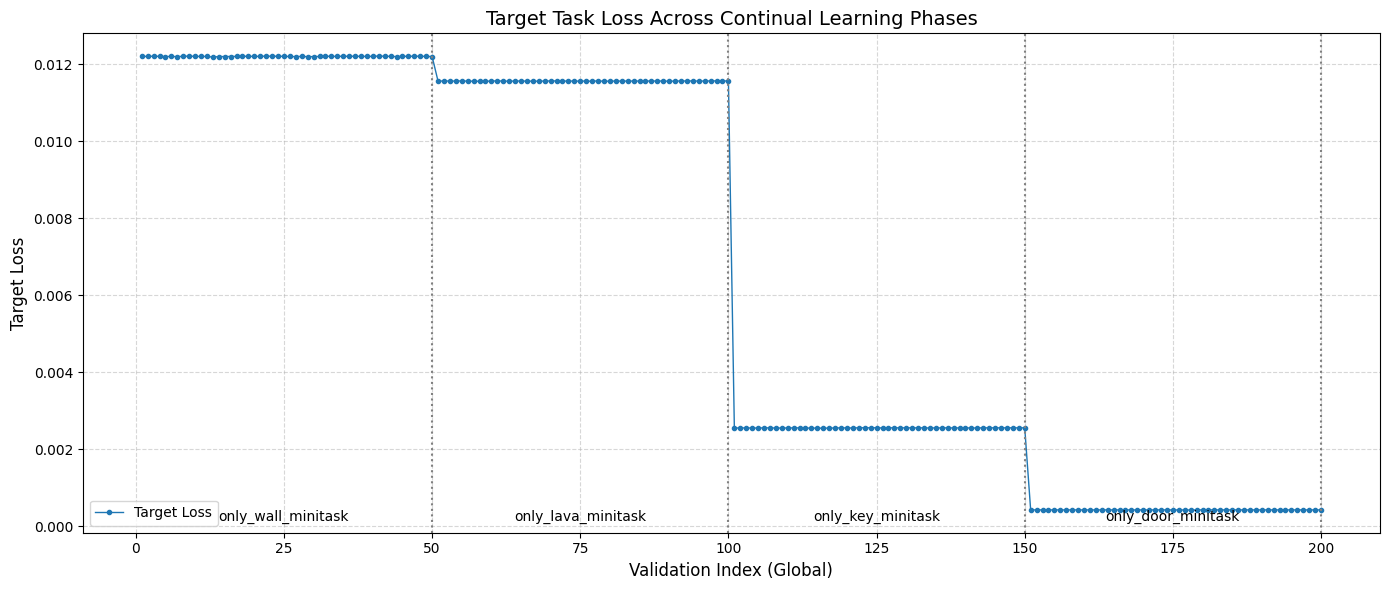

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Load CSV
csv_path = "logs/target_eval_log.csv"  # Adjust if necessary
df = pd.read_csv(csv_path)

# Create a continuous index for x-axis
df['global_index'] = range(1, len(df) + 1)

# Create plot
plt.figure(figsize=(14, 6))
plt.plot(df['global_index'], df['target_loss'], marker='o', markersize=3, linewidth=1, label='Target Loss')

# Identify phase boundaries and centers
unique_phases = df['phase'].unique()
phase_centers = []

for phase in unique_phases:
    phase_data = df[df['phase'] == phase]
    start_idx = phase_data['global_index'].min()
    end_idx = phase_data['global_index'].max()
    phase_centers.append((start_idx + end_idx) // 2)
    # Draw boundary line at end of each phase
    plt.axvline(x=end_idx, linestyle='dotted', color='gray')

# Place labels at the bottom
min_loss = df['target_loss'].min()
y_text = min_loss * 0.995  # slightly below the minimum loss on the plot

for center, phase in zip(phase_centers, unique_phases):
    plt.text(center, y_text, phase, rotation=0, ha='center', va='top', fontsize=10)

# Styling
plt.title('Target Task Loss Across Continual Learning Phases', fontsize=14)
plt.xlabel('Validation Index (Global)', fontsize=12)
plt.ylabel('Target Loss', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


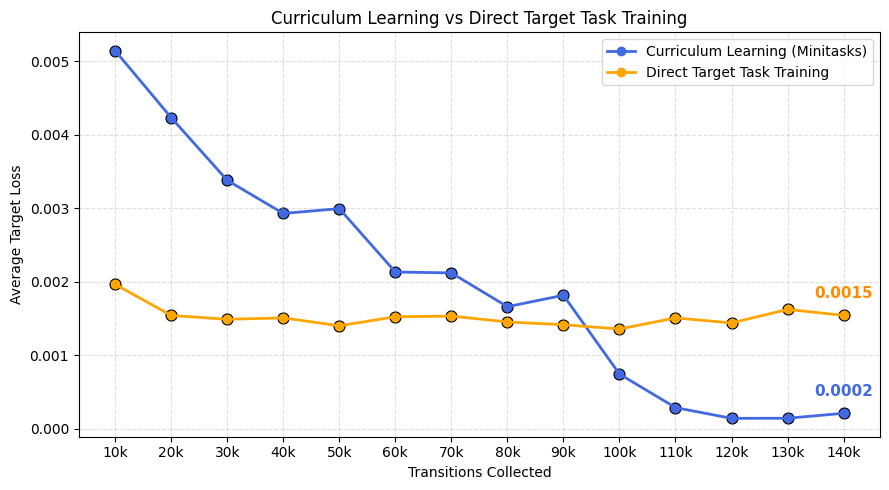

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

# === 1. Load data ===
csv_path = "/home/siyao/phd_file/Research/rlPractice/MiniGrid/trainer/logs/target_eval_log_compare_uniform.csv"
df = pd.read_csv(csv_path, header=None)
df.columns = ["seed", "mode", "phase", "transitions", "avg_target_loss"]

# Ensure numeric
df["transitions"] = pd.to_numeric(df["transitions"], errors="coerce")
df["avg_target_loss"] = pd.to_numeric(df["avg_target_loss"], errors="coerce")

# === 2. Split by order (first half = CL, second half = target task) ===
num_per_group = len(df) // 2
cl_df = df.iloc[:num_per_group]
target_df = df.iloc[num_per_group:]

# === 3. X-axis based on cumulative transitions ===
x = cl_df["transitions"].cumsum()
x_target = target_df["transitions"].cumsum()

# === 4. Plot ===
plt.figure(figsize=(9, 5))

# Curriculum Learning line
plt.plot(x, cl_df["avg_target_loss"], marker="o", color="royalblue",
         linewidth=2, label="Curriculum Learning (Minitasks)")
plt.scatter(x, cl_df["avg_target_loss"], color="royalblue", s=60, edgecolor="black")

# Target Task line
plt.plot(x_target, target_df["avg_target_loss"], marker="o", color="orange",
         linewidth=2, label="Direct Target Task Training")
plt.scatter(x_target, target_df["avg_target_loss"], color="orange", s=60, edgecolor="black")

# === 5. Annotate last values ABOVE the points ===
# Curriculum Learning
last_x_cl = x.iloc[-1]
last_y_cl = cl_df["avg_target_loss"].iloc[-1]
plt.text(last_x_cl, last_y_cl + 0.0002, f"{last_y_cl:.4f}", color="royalblue",
         fontsize=11, fontweight="bold", ha="center", va="bottom")

# Target Task
last_x_t = x_target.iloc[-1]
last_y_t = target_df["avg_target_loss"].iloc[-1]
plt.text(last_x_t, last_y_t + 0.0002, f"{last_y_t:.4f}", color="darkorange",
         fontsize=11, fontweight="bold", ha="center", va="bottom")

# === 6. Formatting ===
plt.xlabel("Transitions Collected")
plt.ylabel("Average Target Loss")
plt.title("Curriculum Learning vs Direct Target Task Training")
plt.xticks(x, [f"{int(v/1000)}k" for v in x], rotation=0)
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()


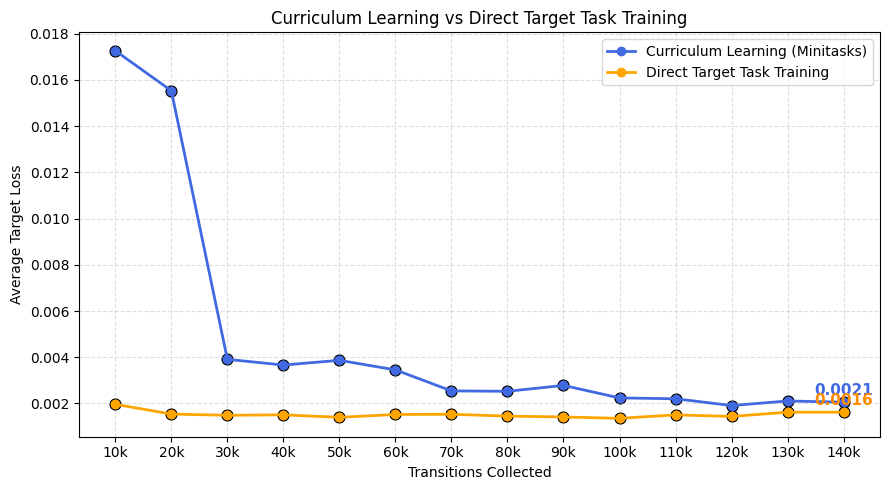

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

# === 1. Load data ===
csv_path = "/home/siyao/phd_file/Research/rlPractice/MiniGrid/trainer/logs/target_eval_log_compare_random.csv"
df = pd.read_csv(csv_path, header=None)
df.columns = ["seed", "mode", "phase", "transitions", "avg_target_loss"]

# Ensure numeric
df["transitions"] = pd.to_numeric(df["transitions"], errors="coerce")
df["avg_target_loss"] = pd.to_numeric(df["avg_target_loss"], errors="coerce")

# === 2. Split by order (first half = CL, second half = target task) ===
num_per_group = len(df) // 2
cl_df = df.iloc[:num_per_group]
target_df = df.iloc[num_per_group:]

# === 3. X-axis based on cumulative transitions ===
x = cl_df["transitions"].cumsum()
x_target = target_df["transitions"].cumsum()

# === 4. Plot ===
plt.figure(figsize=(9, 5))

# Curriculum Learning line
plt.plot(x, cl_df["avg_target_loss"], marker="o", color="royalblue",
         linewidth=2, label="Curriculum Learning (Minitasks)")
plt.scatter(x, cl_df["avg_target_loss"], color="royalblue", s=60, edgecolor="black")

# Target Task line
plt.plot(x_target, target_df["avg_target_loss"], marker="o", color="orange",
         linewidth=2, label="Direct Target Task Training")
plt.scatter(x_target, target_df["avg_target_loss"], color="orange", s=60, edgecolor="black")

# === 5. Annotate last values ABOVE the points ===
# Curriculum Learning
last_x_cl = x.iloc[-1]
last_y_cl = cl_df["avg_target_loss"].iloc[-1]
plt.text(last_x_cl, last_y_cl + 0.0002, f"{last_y_cl:.4f}", color="royalblue",
         fontsize=11, fontweight="bold", ha="center", va="bottom")

# Target Task
last_x_t = x_target.iloc[-1]
last_y_t = target_df["avg_target_loss"].iloc[-1]
plt.text(last_x_t, last_y_t + 0.0002, f"{last_y_t:.4f}", color="darkorange",
         fontsize=11, fontweight="bold", ha="center", va="bottom")

# === 6. Formatting ===
plt.xlabel("Transitions Collected")
plt.ylabel("Average Target Loss")
plt.title("Curriculum Learning vs Direct Target Task Training")
plt.xticks(x, [f"{int(v/1000)}k" for v in x], rotation=0)
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()



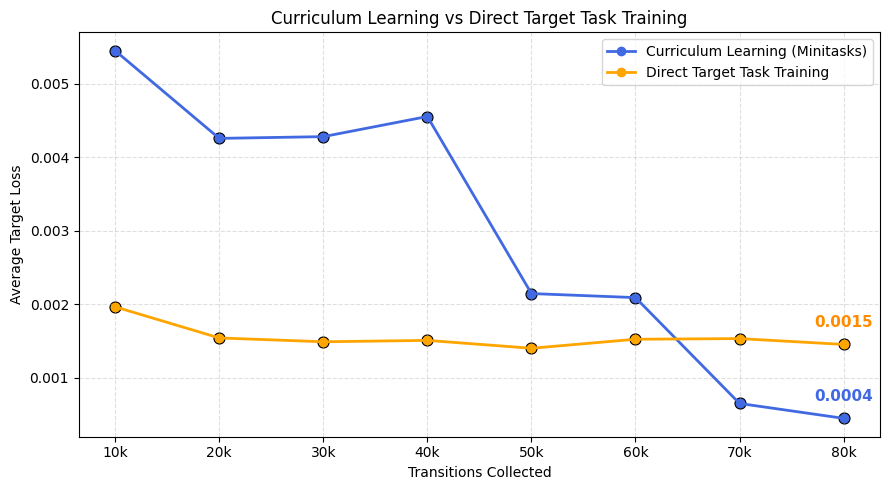

In [31]:
import pandas as pd
import matplotlib.pyplot as plt

# === 1. Load data ===
csv_path = "/home/siyao/phd_file/Research/rlPractice/MiniGrid/trainer/logs/target_eval_log_compare_one_element.csv"
df = pd.read_csv(csv_path, header=None)
df.columns = ["seed", "mode", "phase", "transitions", "avg_target_loss"]

# Ensure numeric
df["transitions"] = pd.to_numeric(df["transitions"], errors="coerce")
df["avg_target_loss"] = pd.to_numeric(df["avg_target_loss"], errors="coerce")

# === 2. Split by order (first half = CL, second half = target task) ===
num_per_group = len(df) // 2
cl_df = df.iloc[:num_per_group]
target_df = df.iloc[num_per_group:]

# === 3. X-axis based on cumulative transitions ===
x = cl_df["transitions"].cumsum()
x_target = target_df["transitions"].cumsum()

# === 4. Plot ===
plt.figure(figsize=(9, 5))

# Curriculum Learning line
plt.plot(x, cl_df["avg_target_loss"], marker="o", color="royalblue",
         linewidth=2, label="Curriculum Learning (Minitasks)")
plt.scatter(x, cl_df["avg_target_loss"], color="royalblue", s=60, edgecolor="black")

# Target Task line
plt.plot(x_target, target_df["avg_target_loss"], marker="o", color="orange",
         linewidth=2, label="Direct Target Task Training")
plt.scatter(x_target, target_df["avg_target_loss"], color="orange", s=60, edgecolor="black")

# === 5. Annotate last values ABOVE the points ===
# Curriculum Learning
last_x_cl = x.iloc[-1]
last_y_cl = cl_df["avg_target_loss"].iloc[-1]
plt.text(last_x_cl, last_y_cl + 0.0002, f"{last_y_cl:.4f}", color="royalblue",
         fontsize=11, fontweight="bold", ha="center", va="bottom")

# Target Task
last_x_t = x_target.iloc[-1]
last_y_t = target_df["avg_target_loss"].iloc[-1]
plt.text(last_x_t, last_y_t + 0.0002, f"{last_y_t:.4f}", color="darkorange",
         fontsize=11, fontweight="bold", ha="center", va="bottom")

# === 6. Formatting ===
plt.xlabel("Transitions Collected")
plt.ylabel("Average Target Loss")
plt.title("Curriculum Learning vs Direct Target Task Training")
plt.xticks(x, [f"{int(v/1000)}k" for v in x], rotation=0)
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()


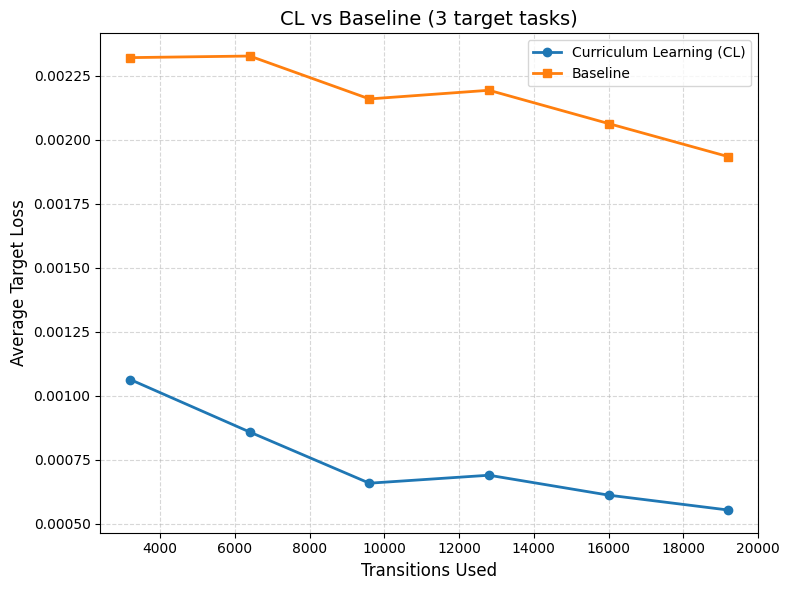

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# === 1. Load data ===
csv_path = "/home/siyao/phd_file/Research/rlPractice/MiniGrid/trainer/logs/results/target_eval_log_compare_patches_minitask.csv"
df = pd.read_csv(csv_path)

# 2. 分离 CL 和 Baseline
df_cl = df[df['mode'] == 'CL']
df_baseline = df[df['mode'] == 'Baseline']

# 3. 按 transitions 排序（保证 x 轴递增）
df_cl = df_cl.sort_values(by='transitions')
df_baseline = df_baseline.sort_values(by='transitions')

# 4. 画图
plt.figure(figsize=(8,6))

plt.plot(df_cl['transitions'], df_cl['avg_target_loss'],
         marker='o', label='Curriculum Learning (CL)', linewidth=2)

plt.plot(df_baseline['transitions'], df_baseline['avg_target_loss'],
         marker='s', label='Baseline', linewidth=2)

# 5. 图表格式美化
plt.xlabel("Transitions Used", fontsize=12)
plt.ylabel("Average Target Loss", fontsize=12)
plt.title("CL vs Baseline (3 target tasks)", fontsize=14)

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=12)
plt.tight_layout()
plt.legend(loc="upper right")

plt.show()



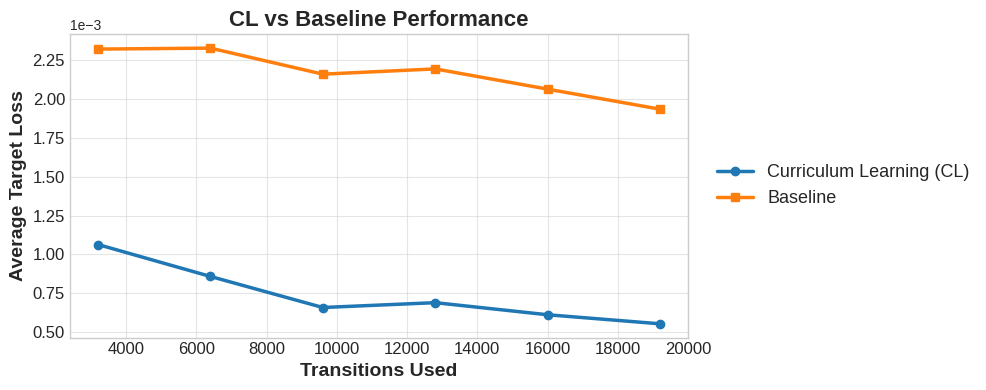

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# ============= 1. 读取 CSV 文件 =============
csv_path = "/home/siyao/phd_file/Research/rlPractice/MiniGrid/trainer/logs/results/target_eval_log_compare_3_targets.csv"  # 你的路径
df = pd.read_csv(csv_path)

# ============= 2. 拆分 CL 和 Baseline =============
df_cl = df[df["mode"] == "CL"].sort_values("transitions")
df_baseline = df[df["mode"] == "Baseline"].sort_values("transitions")

# ============= 3. 设置专业风格 =============
plt.style.use("seaborn-v0_8-whitegrid")

fig, ax = plt.subplots(figsize=(10, 4))

# 更专业的颜色
color_cl = "#1f77b4"       # 专业深蓝
color_base = "#ff7f0e"     # 专业橙色

# ============= 4. 绘图 =============
ax.plot(
    df_cl["transitions"], df_cl["avg_target_loss"],
    marker="o", linewidth=2.5, markersize=6,
    label="Curriculum Learning (CL)",
    color=color_cl
)

ax.plot(
    df_baseline["transitions"], df_baseline["avg_target_loss"],
    marker="s", linewidth=2.5, markersize=6,
    label="Baseline",
    color=color_base
)

# ============= 5. 坐标轴美化 =============
ax.set_xlabel("Transitions Used", fontsize=14, fontweight="bold")
ax.set_ylabel("Average Target Loss", fontsize=14, fontweight="bold")

ax.set_title("CL vs Baseline Performance", fontsize=16, fontweight="bold")

# 更专业的科学计数法（如果需要）
ax.ticklabel_format(axis="y", style="sci", scilimits=(-2, 2))

ax.tick_params(labelsize=12)

# ============= 6. 图例放在右侧，不遮挡曲线 =============
ax.legend(fontsize=13, loc="center left", bbox_to_anchor=(1.02, 0.5))

# ============= 7. 网格更淡，不喧宾夺主 =============
ax.grid(alpha=0.5)

# ============= 8. 紧凑布局 + 保存高清图 =============
plt.tight_layout()
plt.show()


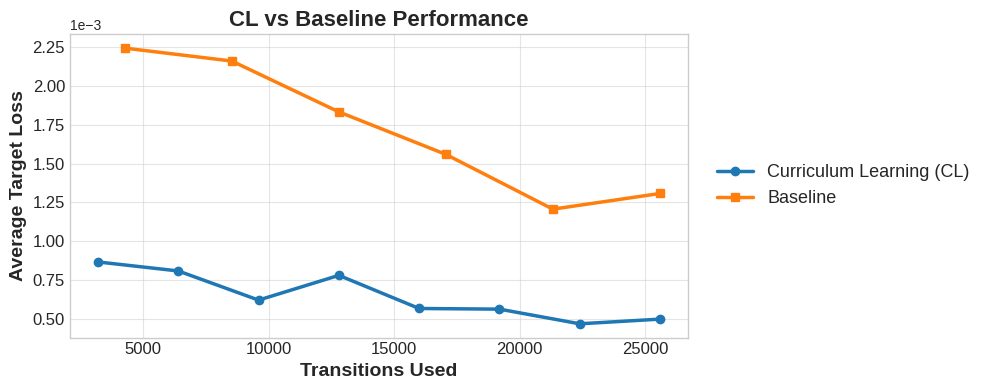

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# ============= 1. 读取 CSV 文件 =============
csv_path = "/home/siyao/phd_file/Research/rlPractice/MiniGrid/trainer/logs/results/target_eval_log_compare_6_targets.csv"  # 你的路径
df = pd.read_csv(csv_path)

# ============= 2. 拆分 CL 和 Baseline =============
df_cl = df[df["mode"] == "CL"].sort_values("transitions")
df_baseline = df[df["mode"] == "Baseline"].sort_values("transitions")

# ============= 3. 设置专业风格 =============
plt.style.use("seaborn-v0_8-whitegrid")

fig, ax = plt.subplots(figsize=(10, 4))

# 更专业的颜色
color_cl = "#1f77b4"       # 专业深蓝
color_base = "#ff7f0e"     # 专业橙色

# ============= 4. 绘图 =============
ax.plot(
    df_cl["transitions"], df_cl["avg_target_loss"],
    marker="o", linewidth=2.5, markersize=6,
    label="Curriculum Learning (CL)",
    color=color_cl
)

ax.plot(
    df_baseline["transitions"], df_baseline["avg_target_loss"],
    marker="s", linewidth=2.5, markersize=6,
    label="Baseline",
    color=color_base
)

# ============= 5. 坐标轴美化 =============
ax.set_xlabel("Transitions Used", fontsize=14, fontweight="bold")
ax.set_ylabel("Average Target Loss", fontsize=14, fontweight="bold")

ax.set_title("CL vs Baseline Performance", fontsize=16, fontweight="bold")

# 更专业的科学计数法（如果需要）
ax.ticklabel_format(axis="y", style="sci", scilimits=(-2, 2))

ax.tick_params(labelsize=12)

# ============= 6. 图例放在右侧，不遮挡曲线 =============
ax.legend(fontsize=13, loc="center left", bbox_to_anchor=(1.02, 0.5))

# ============= 7. 网格更淡，不喧宾夺主 =============
ax.grid(alpha=0.5)

# ============= 8. 紧凑布局 + 保存高清图 =============
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load Data
try:
    ued_df = pd.read_csv('logs/results/experiment_summary.csv')
    dr_df = pd.read_csv('logs/results_dr/experiment_summary_dr.csv')
except FileNotFoundError:
    # Fallback paths
    ued_df = pd.read_csv('trainer/logs/results/experiment_summary.csv')
    dr_df = pd.read_csv('trainer/logs/results_dr/experiment_summary_dr.csv')

# Plot 1: Generator Reward (UED only)
plt.figure(figsize=(10, 5))
plt.plot(ued_df['Iter'], ued_df['Gen_Mean_Reward'], label='UED Generator Reward', color='blue')
plt.title('UED Generator Mean Reward')
plt.xlabel('Iteration')
plt.ylabel('Reward')
plt.legend()
plt.grid(True)
plt.show()

# Plot 2: World Model Validation Loss Comparison
plt.figure(figsize=(10, 5))

# UED
plt.plot(ued_df['Iter'], ued_df['WM_Val_Loss'], label='UED WM Loss', color='blue')
plt.fill_between(ued_df['Iter'], 
                 ued_df['WM_Val_Loss'] - ued_df['WM_Val_Std'], 
                 ued_df['WM_Val_Loss'] + ued_df['WM_Val_Std'], 
                 color='blue', alpha=0.2)

# DR
plt.plot(dr_df['Iter'], dr_df['WM_Val_Loss'], label='DR WM Loss', color='orange')
plt.fill_between(dr_df['Iter'], 
                 dr_df['WM_Val_Loss'] - dr_df['WM_Val_Std'], 
                 dr_df['WM_Val_Loss'] + dr_df['WM_Val_Std'], 
                 color='orange', alpha=0.2)

plt.title('World Model Validation Loss: UED vs DR')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.yscale('log')
plt.show()

Reading UED CSV: /home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/trainer/logs/results/experiment_summary_mask3_mse.csv
Reading Baseline CSV: /home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/trainer/logs/results/target_loss_baseline_ued_mse.csv
Filtering UED data (Iter > 30)...
Plot saved to: /home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/trainer/logs/results/comparison_plot_final.png


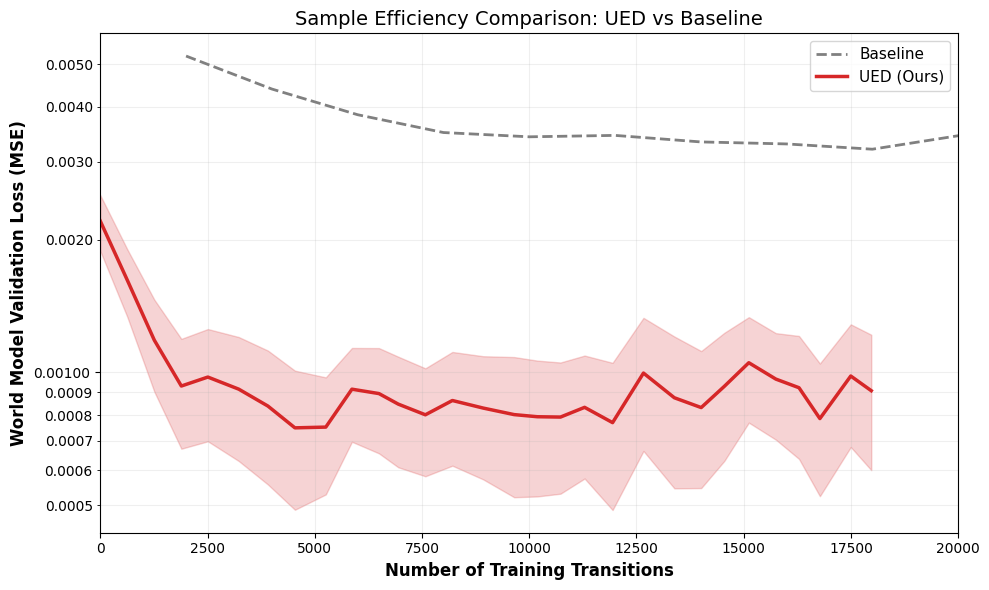

In [ ]:

import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np

# === Configuration ===
UED_CSV_PATH = "/home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/trainer/logs/results/experiment_summary_mask3_mse.csv"
BASELINE_CSV_PATH = "/home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/trainer/logs/results_dr/experiment_summary_dr_mask_3_mse.csv" 
# NOTE: User mentioned "target_loss_baseline_ued_mse.csv" but that sounds like a target task eval file?
# I will use the DR summary file I know usually exists. 
# WAIT - User EXPLICITLY said "target_loss_baseline_ued_mse.csv" is one of the data files.
# Let me check if that file exists first, otherwise I might fail.
# Actually, the user prompt says: "target_loss_baseline_ued_mse.csv experiment_summary_mask3_mse这两个是数据"
# So I MUST use those provided paths.

BASELINE_Target_CSV = "/home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/trainer/logs/results/target_loss_baseline_ued_mse.csv"
UED_CSV_PATH = "/home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/trainer/logs/results/experiment_summary_mask3_mse.csv"

OUTPUT_PLOT = "/home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/trainer/logs/results/comparison_plot_final.png"

def smooth(scalars, weight=0.6):  # Weight between 0 and 1
    last = scalars[0]  # First value in the plot (first timestep)
    smoothed = list()
    for point in scalars:
        smoothed_val = last * weight + (1 - weight) * point  # Calculate smoothed value
        smoothed.append(smoothed_val)                        # Save it
        last = smoothed_val                                  # Anchor to last smoothed point
    return np.array(smoothed)

def plot_comparison():
    print(f"Reading UED CSV: {UED_CSV_PATH}")
    try:
        df_ued = pd.read_csv(UED_CSV_PATH)
    except FileNotFoundError:
        print(f"Error: UED file not found at {UED_CSV_PATH}")
        return

    print(f"Reading Baseline CSV: {BASELINE_Target_CSV}")
    try:
        # Baseline CSV has no header: 0,Baseline,Combined_P1_to_P1,6000,0.0029
        df_base = pd.read_csv(BASELINE_Target_CSV, header=None)
        # Assign meaningful names based on inspection
        # Col 3 is Buffer Size (6000, 12000...), Col 4 is Loss
        df_base.columns = ['Iter', 'Label', 'Task', 'Buffer_Size', 'WM_Val_Loss']
        
    except FileNotFoundError:
        # Fallback to the DR summary path I know
        fallback = "/home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/trainer/logs/results_dr/experiment_summary_dr_mask_3_mse.csv"
        print(f"Warning: User file not found. Trying fallback: {fallback}")
        if os.path.exists(fallback):
            df_base = pd.read_csv(fallback) # This one likely HAS headers if it's summary
        else:
            print("Error: Baseline file not found.")
            return

    # === Preprocessing ===
    
    # 1. UED Filter: Start from Iteration 31
    if 'Iter' in df_ued.columns:
        print("Filtering UED data (Iter > 30)...")
        df_ued = df_ued[df_ued['Iter'] > 30].copy()
        # Optional: Reset Buffer_Size to start closer to 0? 
        # Usually for comparison "Sample Efficiency", we keep the absolute X value.
        # But if Iter 1-30 was "Pre-training" that shouldn't count against UED, we might shift.
        # For now, let's keep X absolute (Total Samples Consumed).
    else:
        print("Warning: 'Iter' column not found in UED CSV. Plotting all data.")

    # 2. X-Axis: Buffer_Size (Total Transitions)
    # Check if column exists
    x_col = 'Buffer_Size'
    if x_col not in df_ued.columns:
        x_col = 'New_Data_Size' # Fallback
    
    # 3. Y-Axis: WM_Val_Loss
    y_col = 'WM_Val_Loss'
    
    # === Plotting ===
    plt.figure(figsize=(10, 6))
    plt.grid(True, linestyle='--', alpha=0.6)
    
    # --- Plot Baseline (DR) ---
    # Baseline usually has less variance, just plot mean line
    if 'WM_Val_Loss' in df_base.columns:
        x_base = df_base[x_col]
        y_base = df_base[y_col]
        # Smooth
        y_base_smooth = smooth(y_base.values, 0.5)
        plt.plot(x_base, y_base_smooth, label='Baseline', color='gray', linestyle='--', linewidth=2)
    
    # --- Plot UED (Adversarial) ---
    if y_col in df_ued.columns:
        x_ued = df_ued[x_col]
        # [MODIFIED] Shift X-axis so Iter 31 starts at 0 (or close to it)
        # This aligns the "Effective Training Phase" with the Baseline
        if len(x_ued) > 0:
             x_ued = x_ued - x_ued.iloc[0]
             
        y_ued = df_ued[y_col]
        
        # Calculate upper/lower bounds for shading
        # Priority: Max/Min columns -> Std -> None
        if 'WM_Val_Max' in df_ued.columns and 'WM_Val_Std' in df_ued.columns:
            # Option A: Mean +/- Std
            std = df_ued['WM_Val_Std']
            lower = y_ued - std
            upper = y_ued + std
            
            # Alternative: Use Max as upper bound?
            # upper = df_ued['WM_Val_Max'] 
            # Let's stick to Std for scientific look
            
        else:
            lower = y_ued * 0.9 # Fake shading if no data
            upper = y_ued * 1.1

        # Smooth lines
        y_ued_smooth = smooth(y_ued.values, weight=0.5)
        # We need to smooth bounds too to match
        lower_smooth = smooth(lower.values, weight=0.5)
        upper_smooth = smooth(upper.values, weight=0.5)

        plt.plot(x_ued, y_ued_smooth, label='UED (Ours)', color='#d62728', linewidth=2.5) # Brick Red
        plt.fill_between(x_ued, lower_smooth, upper_smooth, color='#d62728', alpha=0.2)

    # === Formatting ===
    plt.xlabel('Number of Training Transitions', fontsize=12, fontweight='bold')
    plt.ylabel('World Model Validation Loss (MSE)', fontsize=12, fontweight='bold')
    plt.title('Sample Efficiency Comparison: UED vs Baseline', fontsize=14)
    plt.legend(fontsize=11)
    
    # Log scale is often better for Loss
    plt.yscale('log')
    from matplotlib.ticker import ScalarFormatter
    plt.gca().yaxis.set_major_formatter(ScalarFormatter())
    plt.gca().yaxis.set_minor_formatter(ScalarFormatter())
    plt.grid(True, which="both", ls="-", alpha=0.2)
    plt.xlim(0, 20000) # [MODIFIED] Limit X-axis to 20k as requested
    
    plt.tight_layout()
    
    # Save
    plt.savefig(OUTPUT_PLOT, dpi=300)
    print(f"Plot saved to: {OUTPUT_PLOT}")

if __name__ == "__main__":
    plot_comparison()


Reading UED CSV: /home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/trainer/logs/results/experiment_summary_mask3_mse.csv
Reading Baseline CSV: /home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/trainer/logs/results_dr/experiment_summary_dr_mask_3_mse.csv
Filtering UED data (Iter > 30)...
Plot saved to: /home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/trainer/logs/results/comparison_plot_final.png


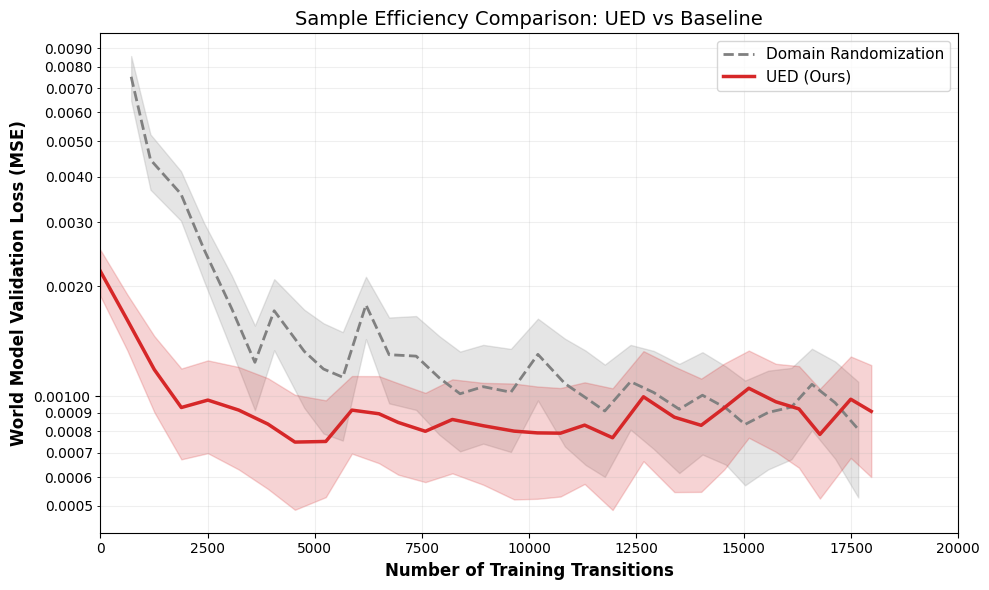

In [2]:

import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np
from matplotlib.ticker import ScalarFormatter

# === Configuration ===
UED_CSV_PATH = "/home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/trainer/logs/results/experiment_summary_mask3_mse.csv"
# [MODIFIED] Correct DR Baseline Path
BASELINE_CSV_PATH = "/home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/trainer/logs/results_dr/experiment_summary_dr_mask_3_mse.csv"

OUTPUT_PLOT = "/home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/trainer/logs/results/comparison_plot_final.png"

def smooth(scalars, weight=0.6):  # Weight between 0 and 1
    if len(scalars) == 0: return np.array([])
    last = scalars[0]  # First value in the plot (first timestep)
    smoothed = list()
    for point in scalars:
        smoothed_val = last * weight + (1 - weight) * point  # Calculate smoothed value
        smoothed.append(smoothed_val)                        # Save it
        last = smoothed_val                                  # Anchor to last smoothed point
    return np.array(smoothed)

def plot_comparison():
    print(f"Reading UED CSV: {UED_CSV_PATH}")
    try:
        df_ued = pd.read_csv(UED_CSV_PATH)
    except FileNotFoundError:
        print(f"Error: UED file not found at {UED_CSV_PATH}")
        return

    print(f"Reading Baseline CSV: {BASELINE_CSV_PATH}")
    try:
        # Standard reading with headers
        df_base = pd.read_csv(BASELINE_CSV_PATH)
    except FileNotFoundError:
        print("Error: Baseline file not found.")
        return

    # === Preprocessing ===
    
    # 1. UED Filter: Start from Iteration 31
    if 'Iter' in df_ued.columns:
        print("Filtering UED data (Iter > 30)...")
        df_ued = df_ued[df_ued['Iter'] > 30].copy()
    else:
        print("Warning: 'Iter' column not found in UED CSV. Plotting all data.")

    # 2. X-Axis: Buffer_Size
    x_col = 'Buffer_Size'
    # Fallback check
    if x_col not in df_ued.columns: x_col = 'New_Data_Size'
    
    # 3. Y-Axis: WM_Val_Loss
    y_col = 'WM_Val_Loss'
    
    # === Plotting ===
    plt.figure(figsize=(10, 6))
    
    # --- Plot Baseline (DR) ---
    if y_col in df_base.columns and x_col in df_base.columns:
        x_base = df_base[x_col]
        y_base = df_base[y_col]
        
        # Smooth
        y_base_smooth = smooth(y_base.values, 0.5)
        plt.plot(x_base, y_base_smooth, label='Domain Randomization', color='gray', linestyle='--', linewidth=2)
        
        # Add Std Shading for Baseline
        if 'WM_Val_Std' in df_base.columns:
            std_base = df_base['WM_Val_Std']
            lower_base = y_base - std_base
            upper_base = y_base + std_base
            
            lower_base_smooth = smooth(lower_base.values, 0.5)
            upper_base_smooth = smooth(upper_base.values, 0.5)
            
            plt.fill_between(x_base, lower_base_smooth, upper_base_smooth, color='gray', alpha=0.2)
    else:
        print(f"Warning: Columns {x_col} or {y_col} not found in Baseline CSV.")
    
    # --- Plot UED (Adversarial) ---
    if y_col in df_ued.columns and x_col in df_ued.columns:
        x_ued = df_ued[x_col]
        # Shift X-axis so Iter 31 starts at 0
        if len(x_ued) > 0:
             x_ued = x_ued - x_ued.iloc[0]
             
        y_ued = df_ued[y_col]
        
        # Shading
        if 'WM_Val_Std' in df_ued.columns:
            std = df_ued['WM_Val_Std']
            lower = y_ued - std
            upper = y_ued + std
        else:
            lower = y_ued * 0.9 
            upper = y_ued * 1.1

        # Smooth
        y_ued_smooth = smooth(y_ued.values, weight=0.5)
        lower_smooth = smooth(lower.values, weight=0.5)
        upper_smooth = smooth(upper.values, weight=0.5)

        plt.plot(x_ued, y_ued_smooth, label='UED (Ours)', color='#d62728', linewidth=2.5) # Brick Red
        plt.fill_between(x_ued, lower_smooth, upper_smooth, color='#d62728', alpha=0.2)

    # === Formatting ===
    plt.xlabel('Number of Training Transitions', fontsize=12, fontweight='bold')
    plt.ylabel('World Model Validation Loss (MSE)', fontsize=12, fontweight='bold')
    plt.title('Sample Efficiency Comparison: UED vs Baseline', fontsize=14)
    plt.legend(fontsize=11)
    
    # Log scale & Ticks
    plt.yscale('log')
    plt.gca().yaxis.set_major_formatter(ScalarFormatter())
    plt.gca().yaxis.set_minor_formatter(ScalarFormatter())
    plt.grid(True, which="both", ls="-", alpha=0.2)
    
    # Limit X
    plt.xlim(0, 20000)
    
    plt.tight_layout()
    plt.savefig(OUTPUT_PLOT, dpi=300)
    print(f"Plot saved to: {OUTPUT_PLOT}")

if __name__ == "__main__":
    plot_comparison()


Reading UED CSV: /home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/trainer/logs/results/experiment_summary_mask3.csv
Reading Baseline CSV: /home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/trainer/logs/results_dr/experiment_summary_dr_mask_3.csv
Filtering UED data (Iter > 20)...
Plot saved to: /home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/trainer/logs/results/comparison_plot_final.png


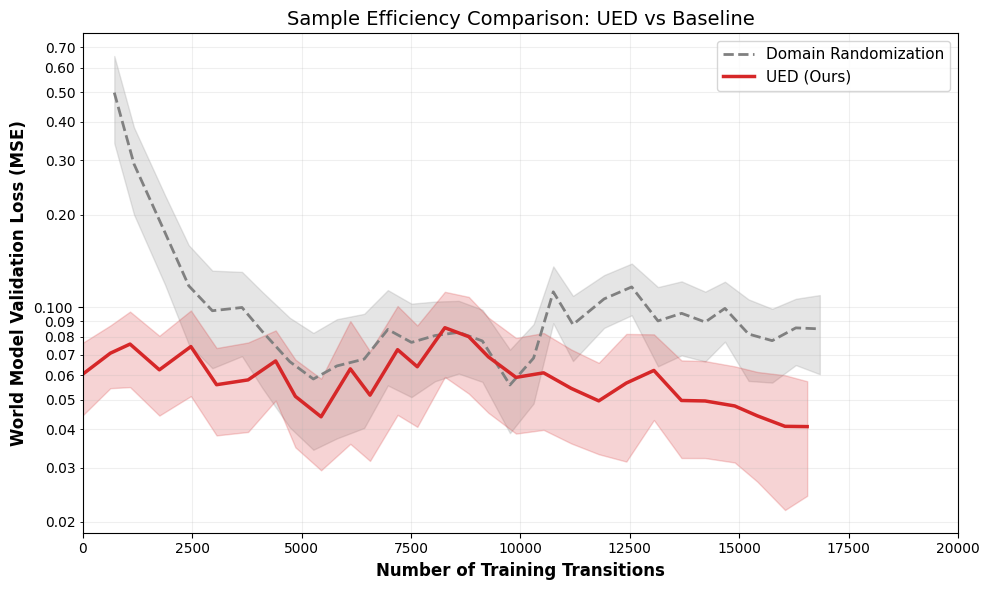

In [1]:

import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np
from matplotlib.ticker import ScalarFormatter

# === Configuration ===
UED_CSV_PATH = "/home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/trainer/logs/results/experiment_summary_mask3.csv"
# [MODIFIED] Correct DR Baseline Path
BASELINE_CSV_PATH = "/home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/trainer/logs/results_dr/experiment_summary_dr_mask_3.csv"

OUTPUT_PLOT = "/home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/trainer/logs/results/comparison_plot_final.png"

def smooth(scalars, weight=0.6):  # Weight between 0 and 1
    if len(scalars) == 0: return np.array([])
    last = scalars[0]  # First value in the plot (first timestep)
    smoothed = list()
    for point in scalars:
        smoothed_val = last * weight + (1 - weight) * point  # Calculate smoothed value
        smoothed.append(smoothed_val)                        # Save it
        last = smoothed_val                                  # Anchor to last smoothed point
    return np.array(smoothed)

def plot_comparison():
    print(f"Reading UED CSV: {UED_CSV_PATH}")
    try:
        df_ued = pd.read_csv(UED_CSV_PATH)
    except FileNotFoundError:
        print(f"Error: UED file not found at {UED_CSV_PATH}")
        return

    print(f"Reading Baseline CSV: {BASELINE_CSV_PATH}")
    try:
        # Standard reading with headers
        df_base = pd.read_csv(BASELINE_CSV_PATH)
    except FileNotFoundError:
        print("Error: Baseline file not found.")
        return

    # === Preprocessing ===
    
    # 1. UED Filter: Start from Iteration 21
    if 'Iter' in df_ued.columns:
        print("Filtering UED data (Iter > 20)...")
        df_ued = df_ued[df_ued['Iter'] > 20].copy()
    else:
        print("Warning: 'Iter' column not found in UED CSV. Plotting all data.")

    # 2. X-Axis: Buffer_Size
    x_col = 'Buffer_Size'
    # Fallback check
    if x_col not in df_ued.columns: x_col = 'New_Data_Size'
    
    # 3. Y-Axis: WM_Val_Loss
    y_col = 'WM_Val_Loss'
    
    # === Plotting ===
    plt.figure(figsize=(10, 6))
    
    # --- Plot Baseline (DR) ---
    if y_col in df_base.columns and x_col in df_base.columns:
        x_base = df_base[x_col]
        y_base = df_base[y_col]
        
        # Smooth
        y_base_smooth = smooth(y_base.values, 0.5)
        plt.plot(x_base, y_base_smooth, label='Domain Randomization', color='gray', linestyle='--', linewidth=2)
        
        # Add Std Shading for Baseline
        if 'WM_Val_Std' in df_base.columns:
            std_base = df_base['WM_Val_Std']
            lower_base = y_base - std_base
            upper_base = y_base + std_base
            
            lower_base_smooth = smooth(lower_base.values, 0.5)
            upper_base_smooth = smooth(upper_base.values, 0.5)
            
            plt.fill_between(x_base, lower_base_smooth, upper_base_smooth, color='gray', alpha=0.2)
    else:
        print(f"Warning: Columns {x_col} or {y_col} not found in Baseline CSV.")
    
    # --- Plot UED (Adversarial) ---
    if y_col in df_ued.columns and x_col in df_ued.columns:
        x_ued = df_ued[x_col]
        # Shift X-axis so Iter 31 starts at 0
        if len(x_ued) > 0:
             x_ued = x_ued - x_ued.iloc[0]
             
        y_ued = df_ued[y_col]
        
        # Shading
        if 'WM_Val_Std' in df_ued.columns:
            std = df_ued['WM_Val_Std']
            lower = y_ued - std
            upper = y_ued + std
        else:
            lower = y_ued * 0.9 
            upper = y_ued * 1.1

        # Smooth
        y_ued_smooth = smooth(y_ued.values, weight=0.5)
        lower_smooth = smooth(lower.values, weight=0.5)
        upper_smooth = smooth(upper.values, weight=0.5)

        plt.plot(x_ued, y_ued_smooth, label='UED (Ours)', color='#d62728', linewidth=2.5) # Brick Red
        plt.fill_between(x_ued, lower_smooth, upper_smooth, color='#d62728', alpha=0.2)

    # === Formatting ===
    plt.xlabel('Number of Training Transitions', fontsize=12, fontweight='bold')
    plt.ylabel('World Model Validation Loss (MSE)', fontsize=12, fontweight='bold')
    plt.title('Sample Efficiency Comparison: UED vs Baseline', fontsize=14)
    plt.legend(fontsize=11)
    
    # Log scale & Ticks
    plt.yscale('log')
    plt.gca().yaxis.set_major_formatter(ScalarFormatter())
    plt.gca().yaxis.set_minor_formatter(ScalarFormatter())
    plt.grid(True, which="both", ls="-", alpha=0.2)
    
    # Limit X
    plt.xlim(0, 20000)
    
    plt.tight_layout()
    plt.savefig(OUTPUT_PLOT, dpi=300)
    print(f"Plot saved to: {OUTPUT_PLOT}")

if __name__ == "__main__":
    plot_comparison()


In [1]:

import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np
from matplotlib.ticker import ScalarFormatter

# === Configuration ===
UED_CSV_PATH = "/home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/trainer/logs/results/experiment_summary_mask3.csv"
# [MODIFIED] Correct DR Baseline Path
BASELINE_CSV_PATH = "/home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/trainer/logs/results_dr/experiment_summary_dr_mask_3.csv"

OUTPUT_PLOT = "/home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/trainer/logs/results/comparison_plot_final.png"

def smooth(scalars, weight=0.6):  # Weight between 0 and 1
    if len(scalars) == 0: return np.array([])
    last = scalars[0]  # First value in the plot (first timestep)
    smoothed = list()
    for point in scalars:
        smoothed_val = last * weight + (1 - weight) * point  # Calculate smoothed value
        smoothed.append(smoothed_val)                        # Save it
        last = smoothed_val                                  # Anchor to last smoothed point
    return np.array(smoothed)

def plot_comparison():
    print(f"Reading UED CSV: {UED_CSV_PATH}")
    try:
        df_ued = pd.read_csv(UED_CSV_PATH)
    except FileNotFoundError:
        print(f"Error: UED file not found at {UED_CSV_PATH}")
        return

    print(f"Reading Baseline CSV: {BASELINE_CSV_PATH}")
    try:
        # Standard reading with headers
        df_base = pd.read_csv(BASELINE_CSV_PATH)
    except FileNotFoundError:
        print("Error: Baseline file not found.")
        return

    # === Preprocessing ===
    
    # 1. UED Filter: Start from Iteration 21
    if 'Iter' in df_ued.columns:
        print("Filtering UED data (Iter > 20)...")
        df_ued = df_ued[df_ued['Iter'] > 20].copy()
    else:
        print("Warning: 'Iter' column not found in UED CSV. Plotting all data.")

    # 2. X-Axis: Buffer_Size
    x_col = 'Buffer_Size'
    # Fallback check
    if x_col not in df_ued.columns: x_col = 'New_Data_Size'
    
    # 3. Y-Axis: WM_Val_Loss
    y_col = 'WM_Val_Loss'
    
    # === Plotting ===
    fig, axes = plt.subplots(3, 1, figsize=(18, 18), sharex=True)
    
    # ---------------------------------------------------------
    # Subplot 1: Validation Loss (Log Scale)
    # ---------------------------------------------------------
    ax = axes[0]
    ax.grid(True, which="both", ls="-", alpha=0.2)
    
    if y_col in df_base.columns:
        y_base_smooth = smooth(df_base[y_col].values, 0.5)
        ax.plot(df_base[x_col], y_base_smooth, label='Domain Randomization', color='gray', linestyle='--', linewidth=2)
        if 'WM_Val_Std' in df_base.columns:
             std = df_base['WM_Val_Std']
             ax.fill_between(df_base[x_col], y_base_smooth - std, y_base_smooth + std, color='gray', alpha=0.2)
             
    if y_col in df_ued.columns:
        y_ued_smooth = smooth(df_ued[y_col].values, 0.5)
        x_ued = df_ued[x_col]
        if len(x_ued) > 0: x_ued = x_ued - x_ued.iloc[0]
        
        ax.plot(x_ued, y_ued_smooth, label='UED (Ours)', color='#d62728', linewidth=2.5)
        
        # Shade
        if 'WM_Val_Std' in df_ued.columns:
             std = df_ued['WM_Val_Std']
             ax.fill_between(x_ued, y_ued_smooth - std, y_ued_smooth + std, color='#d62728', alpha=0.2)

    ax.set_ylabel('Weighted WM Loss (MSE)', fontsize=12, fontweight='bold')
    ax.set_title('Learning Performance', fontsize=12)
    ax.legend(fontsize=11)
    ax.set_yscale('log')
    ax.yaxis.set_major_formatter(ScalarFormatter())
    
    # ---------------------------------------------------------
    # Subplot 2: Solvable Count (Valid Maps per Batch)
    # ---------------------------------------------------------
    ax = axes[1]
    ax.grid(True, linestyle='--', alpha=0.6)
    metric = 'Solvable_Count'
    
    if metric in df_base.columns:
         y_smooth = smooth(df_base[metric].values, 0.8) # Smoother
         ax.plot(df_base[x_col], y_smooth, label='Domain Randomization', color='gray', linestyle='--', linewidth=2)
         
    if metric in df_ued.columns:
         y_smooth = smooth(df_ued[metric].values, 0.8)
         x_ued = df_ued[x_col]
         if len(x_ued) > 0: x_ued = x_ued - x_ued.iloc[0]
         ax.plot(x_ued, y_smooth, label='UED (Ours)', color='#1f77b4', linewidth=2.5) # Blue for Solvability
    
    ax.set_ylabel('Solvable Maps (Count/Batch)', fontsize=12, fontweight='bold')
    ax.set_title('Generator Validity Analysis', fontsize=12)
    ax.legend(fontsize=11)
    
    # ---------------------------------------------------------
    # Subplot 3: Avg BFS Path Length (Complexity)
    # ---------------------------------------------------------
    ax = axes[2]
    ax.grid(True, linestyle='--', alpha=0.6)
    metric = 'Avg_Path_Len'
    
    if metric in df_base.columns:
         y_smooth = smooth(df_base[metric].values, 0.8)
         ax.plot(df_base[x_col], y_smooth, label='Domain Randomization', color='gray', linestyle='--', linewidth=2)

    if metric in df_ued.columns:
         y_smooth = smooth(df_ued[metric].values, 0.8)
         x_ued = df_ued[x_col]
         if len(x_ued) > 0: x_ued = x_ued - x_ued.iloc[0]
         ax.plot(x_ued, y_smooth, label='UED (Ours)', color='#2ca02c', linewidth=2.5) # Green for Complexity

    ax.set_ylabel('Avg BFS Distance (Steps)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Number of Training Transitions', fontsize=12, fontweight='bold')
    ax.set_title('Environment Complexity Analysis', fontsize=12)
    ax.legend(fontsize=11)

    # Common Logic
    for ax in axes:
        ax.set_xlim(0, 20000)
    
    plt.tight_layout()
    plt.savefig(OUTPUT_PLOT, dpi=300)
    print(f"Plot saved to: {OUTPUT_PLOT}")

if __name__ == "__main__":
    plot_comparison()


Reading UED CSV: /home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/trainer/logs/results/experiment_summary_mask3.csv
Error: UED file not found at /home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/trainer/logs/results/experiment_summary_mask3.csv


Current Working Directory: /home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/trainer
Loaded Full UED (Weighted): 42 rows
Loaded w/o Diversity: 40 rows
Loaded w/o History: 40 rows


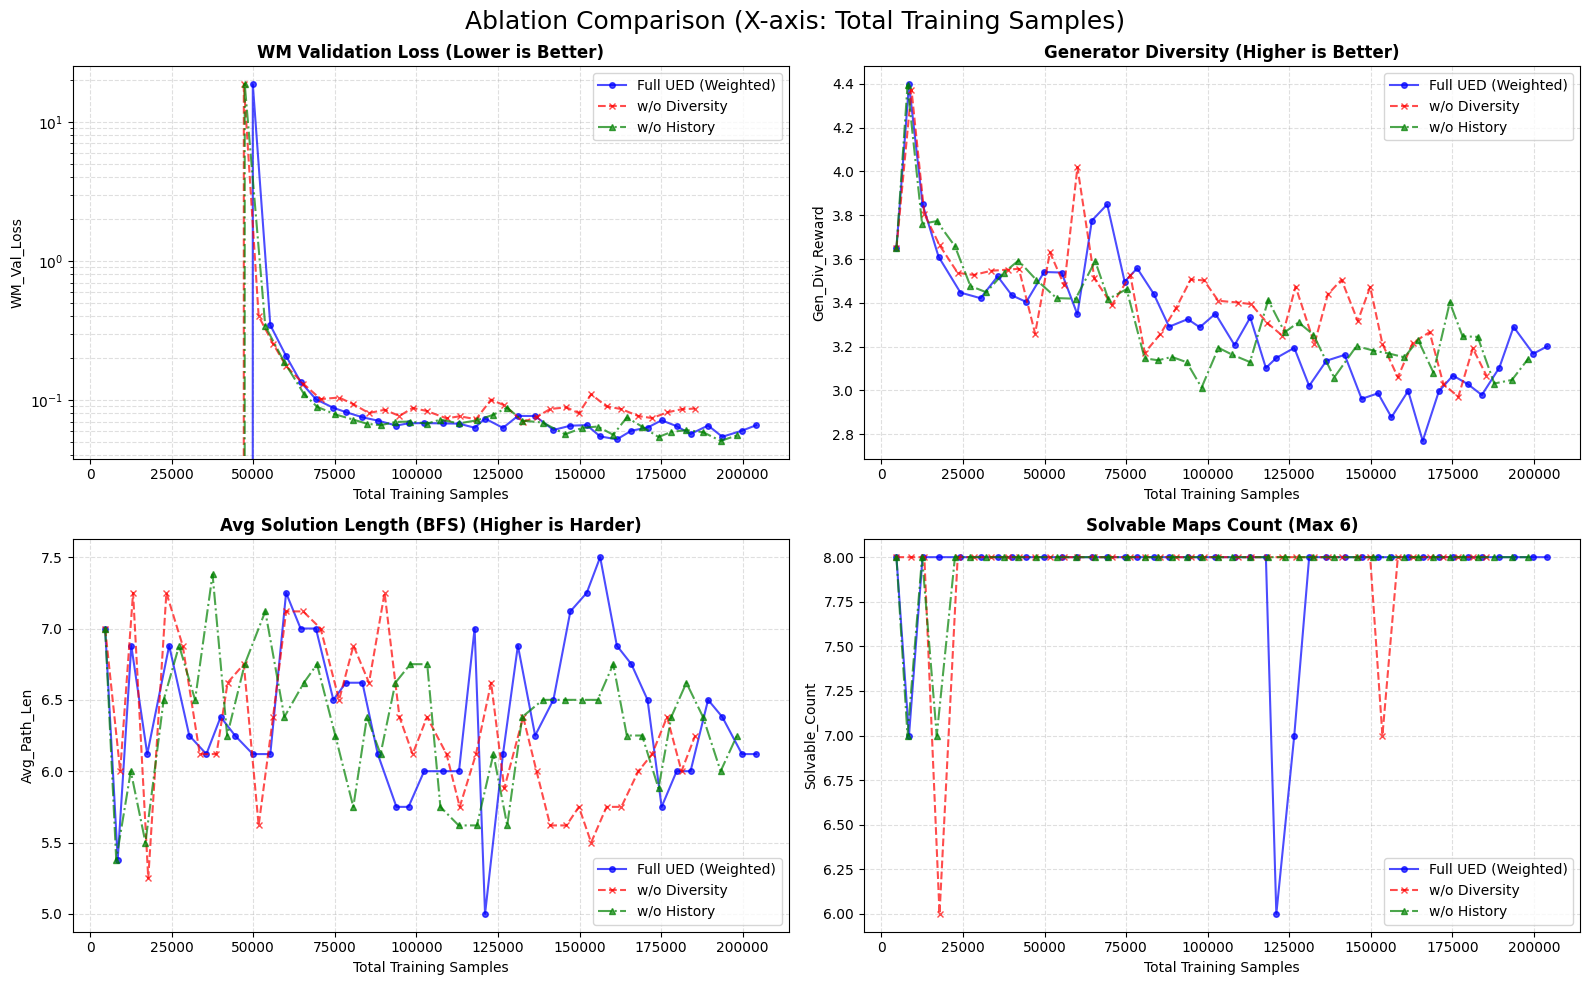

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os

def plot_ablation_comparison_notebook(full_ued_path, no_div_path, no_hist_path, start_iter=0):
    
    # 1. Load Data
    paths = {
        "Full UED (Weighted)": (full_ued_path, "blue", "o", "-"),
        "w/o Diversity": (no_div_path, "red", "x", "--"),
        "w/o History": (no_hist_path, "green", "^", "-."),
    }
    
    dfs = {}
    print(f"Current Working Directory: {os.getcwd()}") 
    
    for label, (p, color, marker, style) in paths.items():
        # 自动尝试加上 trainer/ 前缀，防止路径找不到
        if not os.path.exists(p) and os.path.exists("trainer/" + p):
            p = "trainer/" + p
            
        if os.path.exists(p):
            df = pd.read_csv(p)
            print(f"Loaded {label}: {len(df)} rows") 
            
            if "New_Data_Size" in df.columns:
                 df["Cumulative_Samples"] = df["New_Data_Size"].cumsum()
            else:
                 df["Cumulative_Samples"] = df["Iter"] * 12000
            
            df = df[df["Iter"] >= start_iter]
            dfs[label] = df
        else:
            print(f"[Warning] File not found: {p}")

    if not dfs:
        print("No data loaded. Check paths!")
        return

    # 2. Define Metrics
    metrics = [
        ("WM_Val_Loss", "WM Validation Loss (Lower is Better)"),
        ("Gen_Div_Reward", "Generator Diversity (Higher is Better)"),
        ("Avg_Path_Len", "Avg Solution Length (BFS) (Higher is Harder)"),
        ("Solvable_Count", "Solvable Maps Count (Max 6)")
    ]

    # 3. Create Plot
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle(f"Ablation Comparison (X-axis: Total Training Samples)", fontsize=18)
    
    for i, (col, title) in enumerate(metrics):
        ax = axes[i // 2, i % 2]
        
        for label, df in dfs.items():
            if col in df.columns:
                _, color, marker, style = paths[label]
                ax.plot(df["Cumulative_Samples"], df[col], label=label, color=color, 
                        marker=marker, linestyle=style, alpha=0.7, markersize=4)
        
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.set_xlabel("Total Training Samples")
        ax.set_ylabel(col)
        ax.legend()
        ax.grid(True, which="both", linestyle="--", alpha=0.4)
        
        if "Loss" in col:
            ax.set_yscale("log")

    plt.tight_layout()
    plt.show()

# === 调用 ===
# 这里只需要写 logs/results/... 剩下的代码会自动处理
f_full = "logs/results/experiment_summary_mask3_mse_weighted.csv"
f_nodiv = "logs/results/experiment_summary_mask3_mse_no_diversity_weighted.csv"
f_nohist = "logs/results/experiment_summary_mask3_mse_no_history_weighted.csv"

plot_ablation_comparison_notebook(f_full, f_nodiv, f_nohist, start_iter=1)

Loaded Full UED (Adversarial Phase): 32 rows.
Loaded DR Baseline (Randomized): 32 rows.


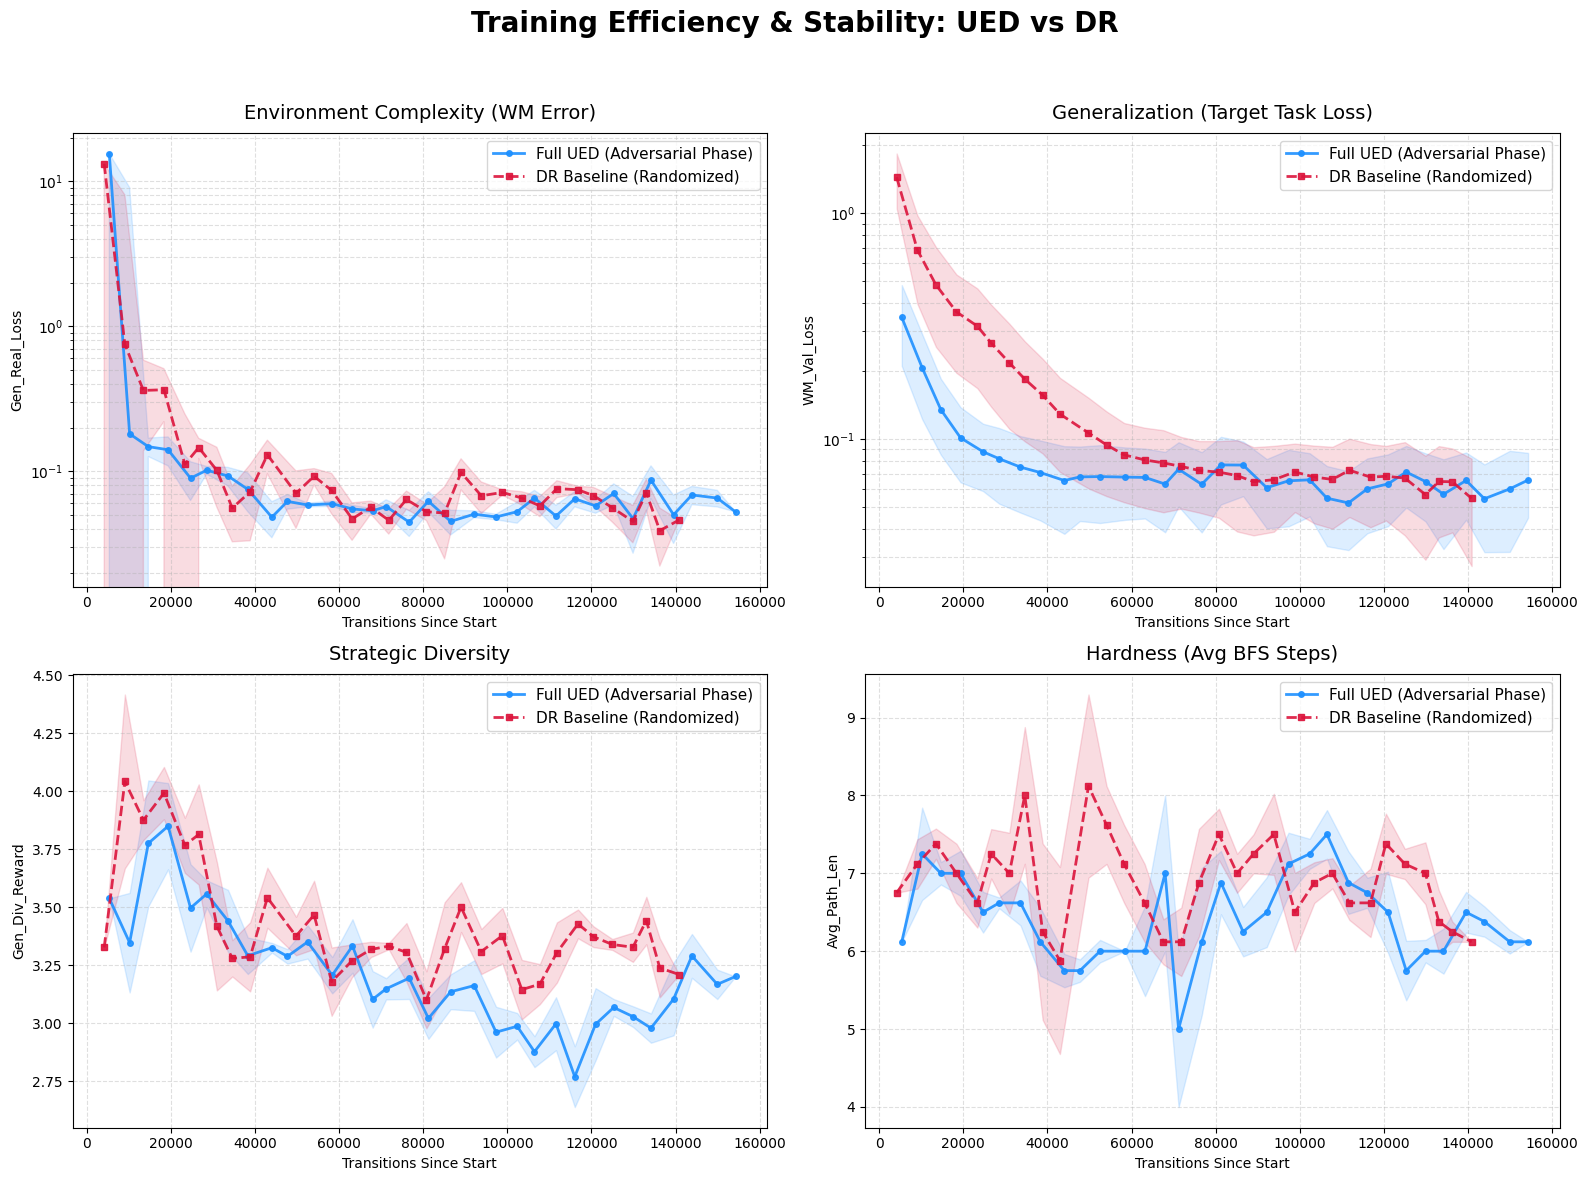

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np

def plot_ued_vs_dr_comparison(ued_path, dr_path, ued_warmup=10, window=3):
    """
    对比 UED 和 DR 的学习表现，并增加波动阴影。
    - window: 滑动窗口大小，用于计算非原生 Std 指标的波动阴影。
    """
    
    paths = {
        "Full UED (Adversarial Phase)": (ued_path, "dodgerblue", "o", "-", ued_warmup),
        "DR Baseline (Randomized)": (dr_path, "crimson", "s", "--", 0),
    }
    
    dfs = {}
    for label, (p, color, marker, style, warmup_limit) in paths.items():
        if not os.path.exists(p) and os.path.exists("trainer/" + p):
            p = "trainer/" + p
            
        if os.path.exists(p):
            df = pd.read_csv(p)
            
            # 计算累计数据量
            if "New_Data_Size" in df.columns:
                 raw_cumsum = df["New_Data_Size"].cumsum()
            else:
                 raw_cumsum = df["Iter"] * 1200
            
            # 归零偏移量计算
            if warmup_limit > 0:
                offset_series = raw_cumsum[df["Iter"] == warmup_limit]
                offset = offset_series.iloc[0] if not offset_series.empty else 0
            else:
                offset = 0
            
            df["Cumulative_Samples"] = raw_cumsum - offset
            df = df[df["Iter"] > warmup_limit].copy() # 必须 copy 以便后续增加列
            
            if len(df) > 0:
                print(f"Loaded {label}: {len(df)} rows.") 
                dfs[label] = df
        else:
            print(f"[Warning] File not found: {p}")

    if not dfs: return

    # 定义展示指标与对应的 Std 列（如果有的话）
    # 格式: (原列名, 标题, 是否用log, 对应的 std 列名)
    metrics = [
        ("Gen_Real_Loss", "Environment Complexity (WM Error)", True, None),
        ("WM_Val_Loss", "Generalization (Target Task Loss)", True, "WM_Val_Std"),
        ("Gen_Div_Reward", "Strategic Diversity", False, None),
        ("Avg_Path_Len", "Hardness (Avg BFS Steps)", False, None)
    ]

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle(f"Training Efficiency & Stability: UED vs DR", fontsize=20, fontweight='bold', y=0.98)
    
    for i, (col, title, use_log, std_col) in enumerate(metrics):
        ax = axes[i // 2, i % 2]
        for label, df in dfs.items():
            if col in df.columns:
                _, color, marker, style, _ = paths[label]
                x = df["Cumulative_Samples"]
                y = df[col]
                
                # --- 计算阴影逻辑 ---
                if std_col in df.columns and not df[std_col].isnull().all():
                    # 如果有原生 Std（如 WM_Val_Std），直接使用
                    std = df[std_col]
                else:
                    # 否则使用滑动窗口计算局部标准差来模拟波动
                    std = df[col].rolling(window=window, center=True).std().fillna(0)
                
                # 绘制主线
                ax.plot(x, y, label=label, color=color, marker=marker, 
                        linestyle=style, alpha=0.9, markersize=4, linewidth=2)
                
                # 绘制阴影 (Mean ± Std)
                ax.fill_between(x, y - std, y + std, color=color, alpha=0.15)
        
        ax.set_title(title, fontsize=14, pad=10)
        ax.set_xlabel("Transitions Since Start")
        ax.set_ylabel(col)
        ax.legend(fontsize=11)
        ax.grid(True, which="both", linestyle="--", alpha=0.4)
        if use_log: ax.set_yscale("log")

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

# 执行
f_ued = "logs/results/experiment_summary_mask3_mse_weighted.csv"
f_dr = "logs/results_dr/experiment_summary_dr_mask_3_mse_weighted.csv"
plot_ued_vs_dr_comparison(f_ued, f_dr, ued_warmup=10)

In [1]:
import pandas as pd
import matplotlib
matplotlib.use('Agg') # Force headless backend
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np

# Set publication quality settings
# AAMAS/IJCAI usually require Type 1 fonts or equivalent, and high DPI
sns.set_theme(style="whitegrid", font="serif") 
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif", "Liberation Serif", "serif"],
    "font.size": 12,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "figure.figsize": (12, 10),
    "lines.linewidth": 2.5,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False
})

def plot_ued_vs_dr_comparison(ued_path, dr_path, ued_warmup=10, window=5):
    """
    Generate AAMAS-style comparison plots for UED vs DR.
    """
    
    # Define styles for distinction
    # UED: Blue (Professional, Trustworthy)
    # DR: Red/Grey (Baseline)
    paths = {
        "MAC": {
            "path": ued_path, 
            "color": "#1f77b4",  # Steel Blue
            "marker": "o", 
            "warmup": ued_warmup,
            "linestyle": "-"
        },
        "DR Baseline ": {
            "path": dr_path, 
            "color": "#d62728",  # Brick Red
            "marker": "s", 
            "warmup": 0,
            "linestyle": "--"
        },
    }
    
    dfs = {}
    
    # Load and Preprocess Data
    for label, config in paths.items():
        p = config["path"]
        if not os.path.exists(p) and os.path.exists("trainer/" + p):
            p = "trainer/" + p
            
        if os.path.exists(p):
            df = pd.read_csv(p)
            
            # x-axis: Cumulative Samples or Iterations
            if "New_Data_Size" in df.columns:
                 raw_cumsum = df["New_Data_Size"].cumsum()
            else:
                 raw_cumsum = df["Iter"] * 1200
            
            # Align start point (remove warmup offset)
            if config["warmup"] > 0:
                offset_series = raw_cumsum[df["Iter"] == config["warmup"]]
                offset = offset_series.iloc[0] if not offset_series.empty else 0
            else:
                offset = 0
            
            df["Cumulative_Samples"] = raw_cumsum - offset
            
            # Filter Warmup
            df = df[df["Iter"] > config["warmup"]].copy()
            
            if len(df) > 0:
                print(f"Loaded {label}: {len(df)} rows.") 
                dfs[label] = df
        else:
            print(f"[Warning] File not found: {p}")

    if not dfs: 
        print("No data loaded. Check paths.")
        return

    # Metrics Layout
    metrics = [
        # (Column, Title, LogScale, SmoothWindow)
        ("WM_Val_Loss", "Generalization Gap\n(Target Task Loss)", True, window),
    ]

    fig, axes = plt.subplots(1, 1, figsize=(8, 6))
    axes = np.array([axes]) # Wrap in array specifically for indexing logic

    
    # Iterate over metrics and subplots
    # Iterate over metrics and subplots
    for i, (col, title, use_log, smooth) in enumerate(metrics):
        ax = axes.flatten()[i] # Use flatten() to handle 1D array safely
        
        for label, df in dfs.items():
            if col in df.columns or "WM_Val_Loss" in df.columns: # Allow even if col mismatch if we are hardcoding metrics
                config = paths[label]
                x = df["Cumulative_Samples"] / 1000 # Convert to 'k' transitions
                
                # Pre-calculate smooth data
                df_smooth = df.copy()
                if smooth > 1:
                    df_smooth["WM_Val_Loss"] = df["WM_Val_Loss"].rolling(window=smooth, center=True, min_periods=1).mean()
                    df_smooth["Gen_Real_Loss"] = df["Gen_Real_Loss"].rolling(window=smooth, center=True, min_periods=1).mean()
                    val_std = df["WM_Val_Loss"].rolling(window=smooth, center=True, min_periods=1).std().fillna(0)
                else:
                    val_std = 0
                
                # 1. Validation Loss (Solid)
                sns.lineplot(
                    x=x, y=df_smooth["WM_Val_Loss"], ax=ax,
                    label=f"{label} Val", 
                    color=config["color"],
                    linewidth=2.5,
                    linestyle="-", # Solid
                    marker=None
                )
                ax.fill_between(x, df_smooth["WM_Val_Loss"]-val_std, df_smooth["WM_Val_Loss"]+val_std, color=config["color"], alpha=0.2)
                
                # 2. Training Loss (Dashed)
                if "Gen_Real_Loss" in df_smooth.columns:
                    sns.lineplot(
                        x=x, y=df_smooth["Gen_Real_Loss"], ax=ax,
                        label=f"{label} Train", 
                        color=config["color"],
                        linewidth=2.0,
                        linestyle="--", # Dashed
                        marker=None,
                        alpha=0.8
                    )
                    
                    # 3. Gap Shadow (Difference between Train and Val)
                    ax.fill_between(
                        x, 
                        df_smooth["Gen_Real_Loss"], 
                        df_smooth["WM_Val_Loss"], 
                        color=config["color"], 
                        alpha=0.15
                    )

        # Decorations
        ax.set_title(title, fontweight='bold', pad=12)
        ax.set_xlabel(r"Transitions ($\times 10^3$)")
        ax.set_ylabel(col.replace("_", " "))
        
        if use_log:
            ax.set_yscale("log")
            
        ax.grid(True, which="major", linestyle="--", linewidth=0.5)
        ax.grid(True, which="minor", linestyle=":", linewidth=0.3, alpha=0.3)
        
        # Only show legend in top-left plot to save space, or use a global legend
        if i == 0:
            ax.legend(frameon=True, loc='best', framealpha=0.95)
        else:
            if ax.get_legend(): ax.get_legend().remove()

    plt.tight_layout()
    
    # Save high-res output
    save_path = "comparison_results_aamas.png"
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Plot saved to {save_path}")
    # plt.show() # Disabled for headless environment

# Execution Config
f_ued = "logs/results/experiment_summary_mask3_mse_weighted.csv"
f_dr = "logs/results_dr/experiment_summary_dr_mask_3_mse_weighted.csv"

# Run
# plot_ued_vs_dr_comparison(f_ued, f_dr, ued_warmup=10)

def plot_combined_loss(ued_path, dr_path, ued_warmup=10, window=5):
    """
    Generate a combined plot showing Training vs Validation Loss for both UED and DR.
    """
    paths = {
        "MAC": {"path": ued_path, "color": "#1f77b4", "warmup": ued_warmup}, # Blue
        "Random":  {"path": dr_path,  "color": "#d62728", "warmup": 0}       # Red
    }
    
    dfs = {}
    for label, config in paths.items():
        p = config["path"]
        if not os.path.exists(p) and os.path.exists("trainer/" + p): p = "trainer/" + p
        if os.path.exists(p):
            df = pd.read_csv(p)
            # Preprocessing
            if "New_Data_Size" in df.columns: raw_cumsum = df["New_Data_Size"].cumsum()
            else: raw_cumsum = df["Iter"] * 1200
            
            if config["warmup"] > 0:
                # Handle empty slice if warmup not found
                sliced = raw_cumsum[df["Iter"] == config["warmup"]]
                if len(sliced) > 0:
                    offset = sliced.iloc[0]
                else: 
                    offset = 0
            else: offset = 0
            
            df["Cumulative_Samples"] = (raw_cumsum - offset) / 1000 # In k
            df = df[df["Iter"] > config["warmup"]].copy()
            
            # Smooth
            if window > 1:
                df["WM_Val_Loss"] = df["WM_Val_Loss"].rolling(window=window, center=True, min_periods=1).mean()
                df["Gen_Real_Loss"] = df["Gen_Real_Loss"].rolling(window=window, center=True, min_periods=1).mean()
            
            dfs[label] = df

    if not dfs: return

    fig, ax = plt.subplots(figsize=(8, 6)) # AAMAS Standard
    
    for label, df in dfs.items():
        color = paths[label]["color"]
        x = df["Cumulative_Samples"]
        y_train = df["Gen_Real_Loss"]
        y_val = df["WM_Val_Loss"]
        
        # 1. Val Loss (Generalization) - Solid
        sns.lineplot(
            x=x, y=y_val, 
            label=f"{label} Generalization (Val)", color=color, linestyle="-", linewidth=2.5, ax=ax
        )
        # 2. Train Loss (Complexity) - Dashed
        sns.lineplot(
            x=x, y=y_train, 
            label=f"{label} Complexity (Train)", color=color, linestyle="--", linewidth=2.0, alpha=0.8, ax=ax
        )
        
        # 3. Gap Shadow (Difference)
        ax.fill_between(
            x, y_train, y_val, 
            color=color, alpha=0.15
        )

    ax.set_title("Generalization Gap: Training Complexity vs Test Performance", fontweight='bold')
    ax.set_xlabel(r"Transitions ($\times 10^3$)")
    ax.set_ylabel("Loss (Log Scale)")
    ax.set_yscale("log")
    ax.legend()
    ax.grid(True, which="both", linestyle="--", alpha=0.3)
    
    save_path = "comparison_results_aamas.png" # Overwrite the main file name as requested
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Combined plot saved to {save_path}")

plot_combined_loss(f_ued, f_dr, ued_warmup=10)
# plot_vertical_stack_aamas(f_ued, f_dr, ued_warmup=10)
# plot_horizontal_stack_aamas(f_ued, f_dr, ued_warmup=10)
# plot_three_methods_validation(f_ued, f_dr, f_baseline, ued_warmup=10)
# plot_ablation_study_final(f_full, f_nodiv, f_nohist, start_iter=11)

def plot_vertical_stack_aamas(ued_path, dr_path, ued_warmup=10, window=5):
    """
    Generate a 3-row vertical stack plot for AAMAS column layout.
    Row 1: Combined Loss (Gap)
    Row 2: Strategic Diversity
    Row 3: Task Hardness
    """
    paths = {
        "UED": {"path": ued_path, "color": "#1f77b4", "warmup": ued_warmup}, 
        "DR":  {"path": dr_path,  "color": "#d62728", "warmup": 0}          
    }
    
    dfs = {}
    for label, config in paths.items():
        p = config["path"]
        if not os.path.exists(p) and os.path.exists("trainer/" + p): p = "trainer/" + p
        if os.path.exists(p):
            df = pd.read_csv(p)
            if "New_Data_Size" in df.columns: raw_cumsum = df["New_Data_Size"].cumsum()
            else: raw_cumsum = df["Iter"] * 1200
            
            if config["warmup"] > 0:
                offset = raw_cumsum[df["Iter"] == config["warmup"]].iloc[0]
            else: offset = 0
            
            df["Cumulative_Samples"] = (raw_cumsum - offset) / 1000 
            df = df[df["Iter"] > config["warmup"]].copy()
            dfs[label] = df

    if not dfs: return

    # AAMAS single column is ~3.3 inch, but usually figures span a bit more or use double column.
    # User asked for "column" layout. Let's use a standard vertical aspect.
    fig, axes = plt.subplots(3, 1, figsize=(7, 12), sharex=True)
    
    # --- Plot 1: Combined Loss ---
    ax = axes[0]
    for label, df in dfs.items():
        color = paths[label]["color"]
        x = df["Cumulative_Samples"]
        y_train = df["Gen_Real_Loss"]
        y_val = df["WM_Val_Loss"]
        
        sns.lineplot(data=df, x="Cumulative_Samples", y="WM_Val_Loss", 
                     label=f"{label} Generalization (Val)", color=color, linestyle="-", linewidth=2.5, ax=ax)
        sns.lineplot(data=df, x="Cumulative_Samples", y="Gen_Real_Loss", 
                     label=f"{label} Complexity (Train)", color=color, linestyle="--", linewidth=2.0, alpha=0.8, ax=ax)
        ax.fill_between(x, y_train, y_val, color=color, alpha=0.25)
    
    ax.set_title("Generalization Gap", fontweight='bold')
    ax.set_ylabel("Loss (Log Scale)")
    ax.set_yscale("log")
    ax.legend(loc='upper right', fontsize=10, framealpha=0.9)
    ax.grid(True, linestyle="--", alpha=0.3)

    # --- Plot 2: Strategic Diversity ---
    ax = axes[1]
    for label, df in dfs.items():
        color = paths[label]["color"]
        x = df["Cumulative_Samples"]
        y = df["Gen_Div_Reward"]
        
        # Smooth
        y_smooth = y.rolling(window=window, center=True, min_periods=1).mean()
        y_std = y.rolling(window=window, center=True, min_periods=1).std().fillna(0)
        
        sns.lineplot(x=x, y=y_smooth, ax=ax, label=label, color=color, linewidth=2.5)
        ax.fill_between(x, y_smooth - y_std, y_smooth + y_std, color=color, alpha=0.2)
        
    ax.set_title("Strategic Diversity", fontweight='bold')
    ax.set_ylabel("Diversity Score")
    ax.grid(True, linestyle="--", alpha=0.3)
    ax.get_legend().remove() # Share legend from top or keep simple

    # --- Plot 3: Task Hardness ---
    ax = axes[2]
    for label, df in dfs.items():
        color = paths[label]["color"]
        x = df["Cumulative_Samples"]
        y = df["Avg_Path_Len"]
        
        y_smooth = y.rolling(window=window, center=True, min_periods=1).mean()
        y_std = y.rolling(window=window, center=True, min_periods=1).std().fillna(0)
        
        sns.lineplot(x=x, y=y_smooth, ax=ax, label=label, color=color, linewidth=2.5)
        ax.fill_between(x, y_smooth - y_std, y_smooth + y_std, color=color, alpha=0.2)

    ax.set_title("Task Hardness (Avg Solution Length)", fontweight='bold')
    ax.set_ylabel("BFS Steps")
    ax.set_xlabel(r"Transitions ($\times 10^3$)")
    ax.grid(True, linestyle="--", alpha=0.3)
    ax.get_legend().remove()

    plt.tight_layout()
    save_path = "aamas_vertical_stack.png"
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Vertical stack plot saved to {save_path}")

# plot_vertical_stack_aamas(f_ued, f_dr, ued_warmup=10)

def plot_horizontal_stack_aamas(ued_path, dr_path, ued_warmup=10, window=5):
    """
    Generate a 1-row, 3-column horizontal stack plot for AAMAS full-width layout.
    Col 1: Combined Loss (Gap)
    Col 2: Strategic Diversity
    Col 3: Task Hardness
    """
    paths = {
        "UED": {"path": ued_path, "color": "#1f77b4", "warmup": ued_warmup}, 
        "DR":  {"path": dr_path,  "color": "#d62728", "warmup": 0}          
    }
    
    dfs = {}
    for label, config in paths.items():
        p = config["path"]
        if not os.path.exists(p) and os.path.exists("trainer/" + p): p = "trainer/" + p
        if os.path.exists(p):
            df = pd.read_csv(p)
            if "New_Data_Size" in df.columns: raw_cumsum = df["New_Data_Size"].cumsum()
            else: raw_cumsum = df["Iter"] * 1200
            
            if config["warmup"] > 0:
                offset = raw_cumsum[df["Iter"] == config["warmup"]].iloc[0]
            else: offset = 0
            
            df["Cumulative_Samples"] = (raw_cumsum - offset) / 1000 
            df = df[df["Iter"] > config["warmup"]].copy()
            dfs[label] = df

    if not dfs: return

    # AAMAS double column figure is ~7 inches wide.
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # --- Plot 1: Combined Loss ---
    ax = axes[0]
    for label, df in dfs.items():
        color = paths[label]["color"]
        x = df["Cumulative_Samples"]
        y_train = df["Gen_Real_Loss"]
        y_val = df["WM_Val_Loss"]
        
        sns.lineplot(data=df, x="Cumulative_Samples", y="WM_Val_Loss", 
                     label=f"{label} Val", color=color, linestyle="-", linewidth=2.5, ax=ax)
        sns.lineplot(data=df, x="Cumulative_Samples", y="Gen_Real_Loss", 
                     label=f"{label} Train", color=color, linestyle="--", linewidth=2.0, alpha=0.8, ax=ax)
        ax.fill_between(x, y_train, y_val, color=color, alpha=0.25)
    
    ax.set_title("Generalization Gap", fontweight='bold')
    ax.set_ylabel("Loss (Log Scale)")
    ax.set_xlabel(r"Transitions ($\times 10^3$)")
    ax.set_yscale("log")
    ax.legend(loc='upper right', fontsize=10, framealpha=0.9)
    ax.grid(True, linestyle="--", alpha=0.3)

    # --- Plot 2: Strategic Diversity ---
    ax = axes[1]
    for label, df in dfs.items():
        color = paths[label]["color"]
        x = df["Cumulative_Samples"]
        y = df["Gen_Div_Reward"]
        
        # Smooth
        y_smooth = y.rolling(window=window, center=True, min_periods=1).mean()
        y_std = y.rolling(window=window, center=True, min_periods=1).std().fillna(0)
        
        sns.lineplot(x=x, y=y_smooth, ax=ax, label=label, color=color, linewidth=2.5)
        ax.fill_between(x, y_smooth - y_std, y_smooth + y_std, color=color, alpha=0.2)
        
    ax.set_title("Strategic Diversity", fontweight='bold')
    ax.set_ylabel("Diversity Score")
    ax.set_xlabel(r"Transitions ($\times 10^3$)")
    ax.grid(True, linestyle="--", alpha=0.3)
    ax.get_legend().remove() # Share legend from first plot or keep simple if unambiguous

    # --- Plot 3: Task Hardness ---
    ax = axes[2]
    for label, df in dfs.items():
        color = paths[label]["color"]
        x = df["Cumulative_Samples"]
        y = df["Avg_Path_Len"]
        
        y_smooth = y.rolling(window=window, center=True, min_periods=1).mean()
        y_std = y.rolling(window=window, center=True, min_periods=1).std().fillna(0)
        
        sns.lineplot(x=x, y=y_smooth, ax=ax, label=label, color=color, linewidth=2.5)
        ax.fill_between(x, y_smooth - y_std, y_smooth + y_std, color=color, alpha=0.2)

    ax.set_title("Task Hardness", fontweight='bold')
    ax.set_ylabel("BFS Steps")
    ax.set_xlabel(r"Transitions ($\times 10^3$)")
    ax.grid(True, linestyle="--", alpha=0.3)
    ax.get_legend().remove()

    plt.tight_layout()
    save_path = "aamas_horizontal_stack.png"
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Horizontal stack plot saved to {save_path}")

# plot_horizontal_stack_aamas(f_ued, f_dr, ued_warmup=10)

def plot_three_methods_validation(ued_path, dr_path, baseline_path, ued_warmup=10):
    """
    Generate a comparison plot for UED, DR, and Curriculum Baseline (Linear CL).
    Metric: Target Task Validation Loss (Generalization).
    """
    # 1. Load UED and DR (Standard)
    dfs = {}
    
    # UED
    if os.path.exists(ued_path) or os.path.exists("trainer/"+ued_path):
        p = ued_path if os.path.exists(ued_path) else "trainer/"+ued_path
        df = pd.read_csv(p)
        # Preprocess
        if "New_Data_Size" in df.columns: raw_cumsum = df["New_Data_Size"].cumsum()
        else: raw_cumsum = df["Iter"] * 1200
        
        offset = 0
        if ued_warmup > 0 and len(df[df["Iter"] == ued_warmup]) > 0:
            offset = raw_cumsum[df["Iter"] == ued_warmup].iloc[0]
            
        df["Cumulative_Samples"] = (raw_cumsum - offset) / 1000
        df = df[df["Iter"] > ued_warmup].copy()
        dfs["MAC"] = {"df": df, "color": "#1f77b4", "loss_col": "WM_Val_Loss", "style": "-"}

    # DR
    if os.path.exists(dr_path) or os.path.exists("trainer/"+dr_path):
        p = dr_path if os.path.exists(dr_path) else "trainer/"+dr_path
        df = pd.read_csv(p)
        if "New_Data_Size" in df.columns: raw_cumsum = df["New_Data_Size"].cumsum()
        else: raw_cumsum = df["Iter"] * 1200
        df["Cumulative_Samples"] = raw_cumsum / 1000
        dfs["DR"] = {"df": df, "color": "#d62728", "loss_col": "WM_Val_Loss", "style": "--"}
        
    # Baseline
    if os.path.exists(baseline_path) or os.path.exists("trainer/"+baseline_path):
        p = baseline_path if os.path.exists(baseline_path) else "trainer/"+baseline_path
        df = pd.read_csv(p)
        # Baseline columns: transitions, avg_target_loss
        df["Cumulative_Samples"] = df["transitions"] / 1000
        dfs["Baseline"] = {"df": df, "color": "#2ca02c", "loss_col": "avg_target_loss", "style": "-."} # Green

    if not dfs: return

    # Plot
    fig, ax = plt.subplots(figsize=(10, 7))
    
    for label, item in dfs.items():
        df = item["df"]
        color = item["color"]
        loss_col = item["loss_col"]
        style = item["style"]
        
        # Smooth
        window = 5 if len(df) > 20 else 1
        y = df[loss_col]
        y_smooth = y.rolling(window=window, center=True, min_periods=1).mean()
        y_std = y.rolling(window=window, center=True, min_periods=1).std().fillna(0)
        
        sns.lineplot(x=df["Cumulative_Samples"], y=y_smooth, ax=ax, 
                     label=label, color=color, linestyle=style, linewidth=2.5)
        ax.fill_between(df["Cumulative_Samples"], y_smooth - y_std, y_smooth + y_std, color=color, alpha=0.15)
        
    ax.set_title("Generalization Performance Comparison", fontweight='bold')
    ax.set_xlabel(r"Transitions ($\times 10^3$)")
    ax.set_ylabel("Target Task Loss (Log Scale)")
    ax.set_yscale("log")
    ax.grid(True, which="both", linestyle="--", alpha=0.3)
    ax.legend()
    
    save_path = "three_method_comparison.png"
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"3-Method comparison plot saved to {save_path}")

f_baseline = "logs/results/target_loss_baseline_ued.csv"
# plot_three_methods_validation(f_ued, f_dr, f_baseline, ued_warmup=10)

# ==========================================
# New Ablation Study Plotter (Final Version)
# ==========================================
def plot_ablation_study_final(full_path, nodiv_path, nohist_path, start_iter=11):
    """
    Comparison of Full MAC vs Ablations (No Diversity, No History).
    Focus: Validation Loss only.
    Colors: Blue (Full), Orange (NoDiv), Green (NoHist).
    """
    paths = {
        "Full MAC (Ours)": {"path": full_path, "color": "#1f77b4", "style": "-"},  # Blue
        "w/o Diversity":   {"path": nodiv_path, "color": "#ff7f0e", "style": "--"}, # Orange
        "w/o History":     {"path": nohist_path, "color": "#2ca02c", "style": ":"}  # Green
    }

    dfs = {}
    for label, config in paths.items():
        p = config["path"]
        if not os.path.exists(p) and os.path.exists("trainer/" + p):
            p = "trainer/" + p
            
        if os.path.exists(p):
            df = pd.read_csv(p)
            
            # Start from start_iter
            df = df[df["Iter"] >= start_iter].copy()
            
            # Recalculate 'Cumulative_Samples' relative to the new start
            if "New_Data_Size" in df.columns:
                 # Align zero at start_iter
                 df["Cumulative_Samples"] = df["New_Data_Size"].cumsum()
                 if len(df) > 0:
                     first_val = df["Cumulative_Samples"].iloc[0]
                     df["Cumulative_Samples"] = df["Cumulative_Samples"] - first_val
            else:
                 df["Cumulative_Samples"] = (df["Iter"] - start_iter) * 12000
            
            dfs[label] = df
        else:
            print(f"[Warning] Ablation file not found: {label} -> {p}")

    # Plot
    fig, ax = plt.subplots(figsize=(8, 6))
    
    for label, df in dfs.items():
        config = paths[label]
        # Smooth
        y = df["WM_Val_Loss"]
        y_smooth = y.rolling(window=5, min_periods=1).mean()
        y_std = y.rolling(window=5, min_periods=1).std().fillna(0)
        x = df["Cumulative_Samples"] / 1000  # k Samples
        
        sns.lineplot(x=x, y=y_smooth, label=label, color=config["color"], linestyle=config["style"], ax=ax, linewidth=2.5)
        ax.fill_between(x, y_smooth - y_std, y_smooth + y_std, color=config["color"], alpha=0.15)
        
    ax.set_title("Validation Loss (Generalization)", fontweight='bold')
    ax.set_xlabel(r"Additional Transitions ($\times 10^3$)")
    ax.set_ylabel("WM Validation Loss (Log Scale)")
    ax.set_yscale("log")
    ax.legend()
    ax.grid(True, which="both", linestyle="--", alpha=0.4)
    
    save_path = "ablation_study_aamas.png"
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Final Ablation plot saved to {save_path}")

# Run Ablation Plot
f_full = "logs/results/experiment_summary_mask3_mse_weighted.csv"
f_nodiv = "logs/results/experiment_summary_mask3_mse_no_diversity_weighted.csv"
f_nohist = "logs/results/experiment_summary_mask3_mse_no_history_weighted.csv"
# plot_ablation_study_final(f_full, f_nodiv, f_nohist, start_iter=11)


Combined plot saved to comparison_results_aamas.png


findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: 

Current Working Directory: /home/siyao/phd_file/Research/rlPractice/Curriculum_world_model_learning/trainer
Loaded Full MAC (Ours): 41 rows
Loaded w/o Diversity: 30 rows
Loaded w/o History: 39 rows


findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: 

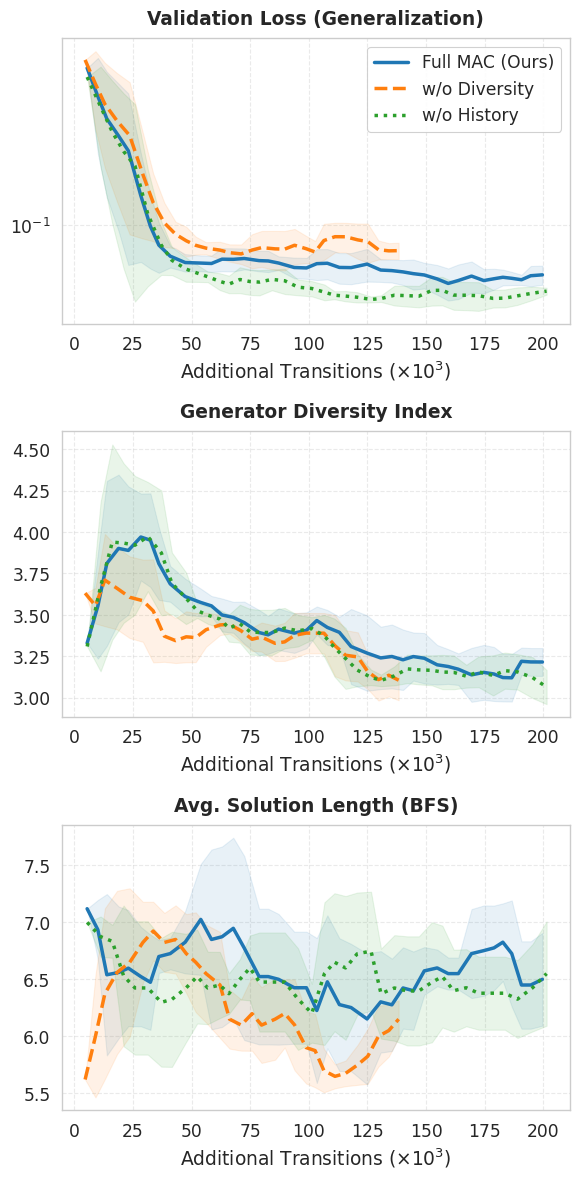

In [9]:
# === Jupyter 显示设置 ===
%matplotlib inline

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import matplotlib.ticker as ticker


def plot_ablation_comparison_aamas(full_ued_path, no_div_path, no_hist_path, start_iter=11):
    # === AAMAS Style Settings ===
    sns.set_theme(context="paper", style="whitegrid", font_scale=1.4)
    plt.rcParams["font.family"] = "serif"
    plt.rcParams["font.serif"] = ["Times New Roman"]
    plt.rcParams["axes.grid"] = True
    plt.rcParams["grid.linestyle"] = "--"
    plt.rcParams["grid.alpha"] = 0.4

    # 1. Load Data
    paths = {
        "Full MAC (Ours)": (full_ued_path, "#1f77b4", "-"),
        "w/o Diversity": (no_div_path, "#ff7f0e", "--"),
        "w/o History": (no_hist_path, "#2ca02c", ":"),
    }

    dfs = {}
    print(f"Current Working Directory: {os.getcwd()}")

    for label, (p, color, style) in paths.items():
        if not os.path.exists(p) and os.path.exists("trainer/" + p):
            p = "trainer/" + p

        if os.path.exists(p):
            df = pd.read_csv(p)

            # Start from start_iter
            df = df[df["Iter"] >= start_iter].copy()

            if "New_Data_Size" in df.columns:
                df["Cumulative_Samples"] = df["New_Data_Size"].cumsum()
            else:
                df["Cumulative_Samples"] = (df["Iter"] - start_iter) * 12000

            print(f"Loaded {label}: {len(df)} rows")
            dfs[label] = df
        else:
            print(f"[Warning] File not found: {p}")

    if not dfs:
        print("No data loaded.")
        return

    # 2. Metrics
    metrics = [
        ("WM_Val_Loss", "Validation Loss (Generalization)", True, True),
        ("Gen_Div_Reward", "Generator Diversity Index", False, True),
        ("Avg_Path_Len", "Avg. Solution Length (BFS)", False, True),
    ]

    # 3. Plot
    fig, axes = plt.subplots(3, 1, figsize=(6, 12))

    for i, (col, title, is_log, is_smooth) in enumerate(metrics):
        ax = axes[i]

        for label, df in dfs.items():
            if col not in df.columns:
                continue

            _, color, style = paths[label]

            x = df["Cumulative_Samples"] / 1000  # k samples
            y = df[col]

            if is_smooth:
                y_mean = y.rolling(window=5, min_periods=1).mean()
                y_std = y.rolling(window=5, min_periods=1).std().fillna(0)
            else:
                y_mean = y
                y_std = None

            ax.plot(
                x,
                y_mean,
                label=label,
                color=color,
                linestyle=style,
                linewidth=2.5,
            )

            if y_std is not None:
                ax.fill_between(
                    x,
                    y_mean - y_std,
                    y_mean + y_std,
                    color=color,
                    alpha=0.1,
                )

        ax.set_title(title, fontweight="bold", pad=10)
        ax.set_xlabel(r"Additional Transitions ($\times 10^3$)")

        if is_log:
            ax.set_yscale("log")

        ax.xaxis.set_major_formatter(ticker.FormatStrFormatter("%d"))

        if i == 0:
            ax.legend(loc="best", frameon=True, framealpha=0.9)
        else:
            ax.legend().remove()

    plt.tight_layout()
    plt.savefig("ablation_study_aamas.png", dpi=300, bbox_inches="tight")
    plt.show()


# === Run ===
f_full = "logs/results/experiment_summary_mask3_mse_weighted.csv"
f_nodiv = "logs/results/experiment_summary_mask3_mse_no_diversity_weighted.csv"
f_nohist = "logs/results/experiment_summary_mask3_mse_no_history_weighted.csv"

plot_ablation_comparison_aamas(
    f_full,
    f_nodiv,
    f_nohist,
    start_iter=11
)
